In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/models/f2000164/svm-single-model/scikitlearn/default/1/svm_single_model.joblib
/kaggle/input/models/f2000164/final-blend-model/scikitlearn/default/1/final_blend_model.joblib
/kaggle/input/models/f2000164/le-full-pipeline/scikitlearn/default/1/lr_full_pipeline.joblib
/kaggle/input/models/f2000164/lgb-full-bundle/scikitlearn/default/1/lgb_full_bundle.joblib
/kaggle/input/models/f2000164/lgb-svd/scikitlearn/default/1/lgb_svd_model.joblib
/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
# from sklearn.preprocessing import OneHotEncoder
# genderEncode=OneHotEncoder(handle_unknown='ignore')
# genderEncode.fit(data[['gender']])

# Toxic Comment Classification
### MLP Project — Jan 2026

This notebook builds a multi-class text classification pipeline to detect toxic comments across four severity levels. The approach combines classical NLP (TF-IDF) with handcrafted linguistic features, trained using Logistic Regression and LightGBM, then blended for best performance.

**Target variable:** `label` — 4 classes (0 = non-toxic, 1 = identity-based, 2 = general toxic, 3 = threat/severe)




---
##  Imports and Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
import warnings
import unicodedata
import os

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, log_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

RANDOM_STATE = 42
N_FOLDS      = 3
N_CLASSES    = 4
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
##  Load Data

In [4]:
# Update these paths before running on Kaggle
TRAIN_PATH  =  '/kaggle/input/comment-category-prediction-challenge/train.csv'
TEST_PATH   =  '/kaggle/input/comment-category-prediction-challenge/test.csv'
SAMPLE_PATH =  '/kaggle/input/comment-category-prediction-challenge/Sample.csv'
 
 
 

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print()
print('First few rows of training data:')
train.head()

Train shape : (198000, 15)
Test shape  : (102000, 14)

First few rows of training data:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


---
##  Exploratory Data Analysis (EDA)

Before building any model, it is important to understand the structure and distribution of the data. This section covers:
- Label distribution
- Text length patterns
- Missing value analysis
- Key relationships between features and the target

In [5]:
# Basic dataset info
print('Dataset Info')
print('-' * 40)
print(f'Total training samples : {len(train):,}')
print(f'Total test samples     : {len(test):,}')
print(f'Number of columns      : {train.shape[1]}')
print()
print('Column names:')
print(train.columns.tolist())
print()
print('Data types:')
print(train.dtypes)

Dataset Info
----------------------------------------
Total training samples : 198,000
Total test samples     : 102,000
Number of columns      : 15

Column names:
['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

Data types:
created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object


Label Distribution:
        Count  Percent
Label                 
0      114173    57.66
1       15918     8.04
2       62440    31.54
3        5469     2.76


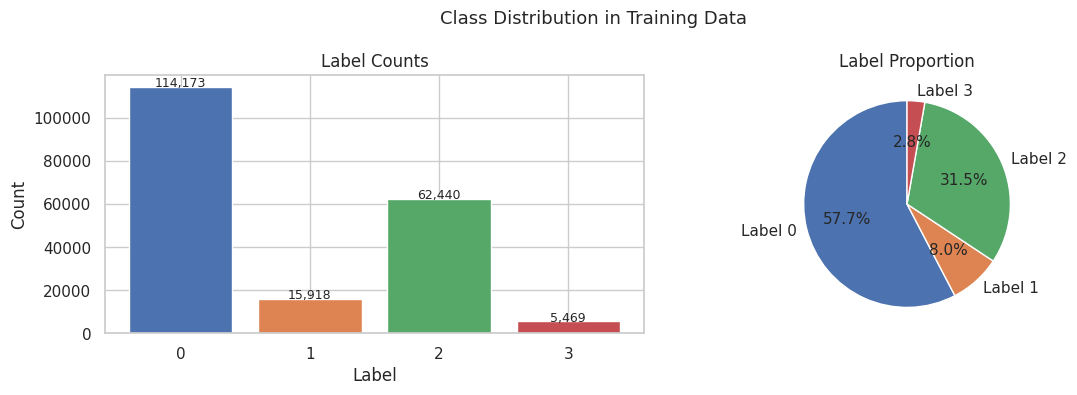


Note: The dataset is highly imbalanced. Label 3 (threats) makes up only ~2.8%.
This will require special handling via class weights during training.


In [6]:
# Label distribution
label_counts = train['label'].value_counts().sort_index()
label_pct    = (label_counts / len(train) * 100).round(2)

label_df = pd.DataFrame({
    'Count'  : label_counts,
    'Percent': label_pct
})
label_df.index.name = 'Label'
print('Label Distribution:')
print(label_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(label_counts.index.astype(str), label_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[0].set_title('Label Counts')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(label_counts.values, labels=[f'Label {i}' for i in label_counts.index],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868','#C44E52'],
            startangle=90)
axes[1].set_title('Label Proportion')

plt.suptitle('Class Distribution in Training Data', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNote: The dataset is highly imbalanced. Label 3 (threats) makes up only ~2.8%.')
print('This will require special handling via class weights during training.')

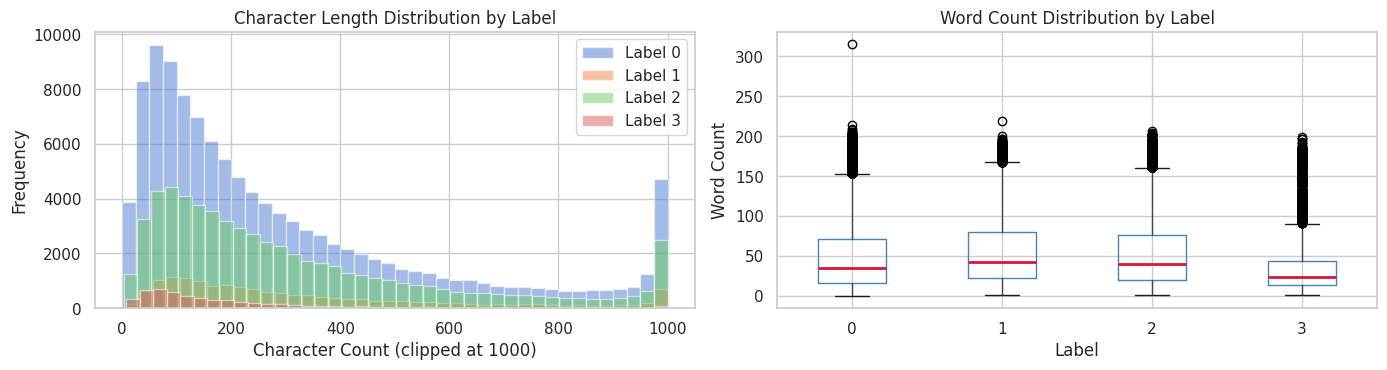

Average word count per label:
label
0    51.2
1    57.2
2    54.9
3    35.0
Name: word_len, dtype: float64


In [7]:
# Text length analysis
train['text_len']  = train['comment'].fillna('').apply(len)
train['word_len']  = train['comment'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl in range(N_CLASSES):
    subset = train[train['label'] == lbl]['text_len']
    axes[0].hist(subset.clip(0, 1000), bins=40, alpha=0.5, label=f'Label {lbl}')
axes[0].set_title('Character Length Distribution by Label')
axes[0].set_xlabel('Character Count (clipped at 1000)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

train.boxplot(column='word_len', by='label', ax=axes[1],
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='crimson', linewidth=2))
axes[1].set_title('Word Count Distribution by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Average word count per label:')
print(train.groupby('label')['word_len'].mean().round(1))

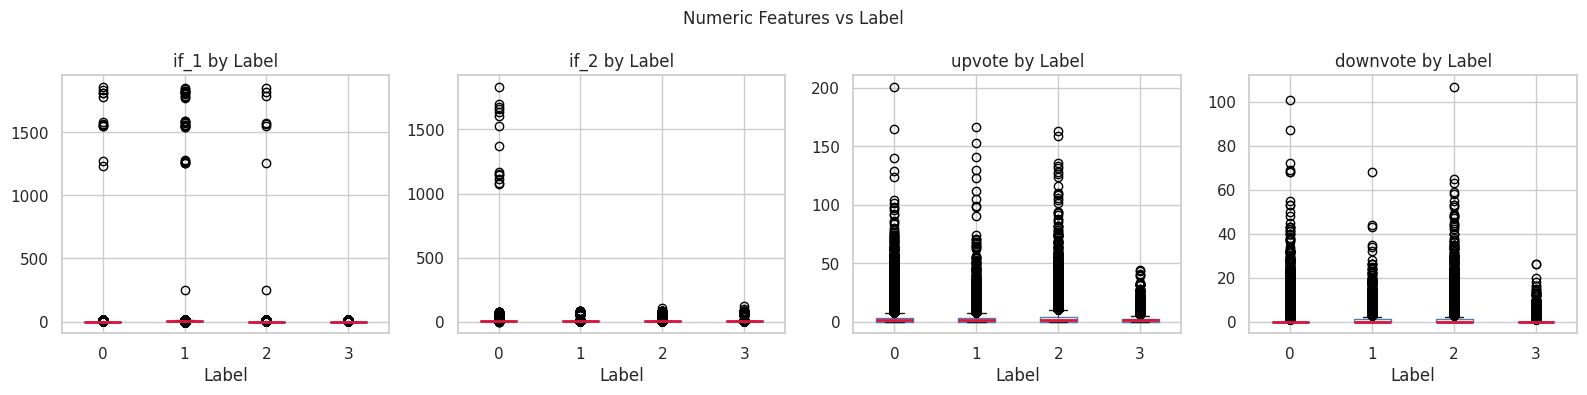

Median values per label:
       if_1  if_2  upvote  downvote
label                              
0       0.0   4.0     1.0       0.0
1       4.0  10.0     1.0       0.0
2       0.0  10.0     1.0       0.0
3       0.0  10.0     1.0       0.0


In [8]:
# Numeric feature relationships with label
numeric_cols = ['if_1', 'if_2', 'upvote', 'downvote']
existing_num = [c for c in numeric_cols if c in train.columns]

if existing_num:
    fig, axes = plt.subplots(1, len(existing_num), figsize=(4*len(existing_num), 4))
    if len(existing_num) == 1:
        axes = [axes]
    for ax, col in zip(axes, existing_num):
        train.boxplot(column=col, by='label', ax=ax,
                      boxprops=dict(color='steelblue'),
                      medianprops=dict(color='crimson', linewidth=2))
        ax.set_title(f'{col} vs Label')
        ax.set_xlabel('Label')
        plt.sca(ax)
        plt.title(f'{col} by Label')
    plt.suptitle('Numeric Features vs Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print('Median values per label:')
    print(train.groupby('label')[existing_num].median().round(2))

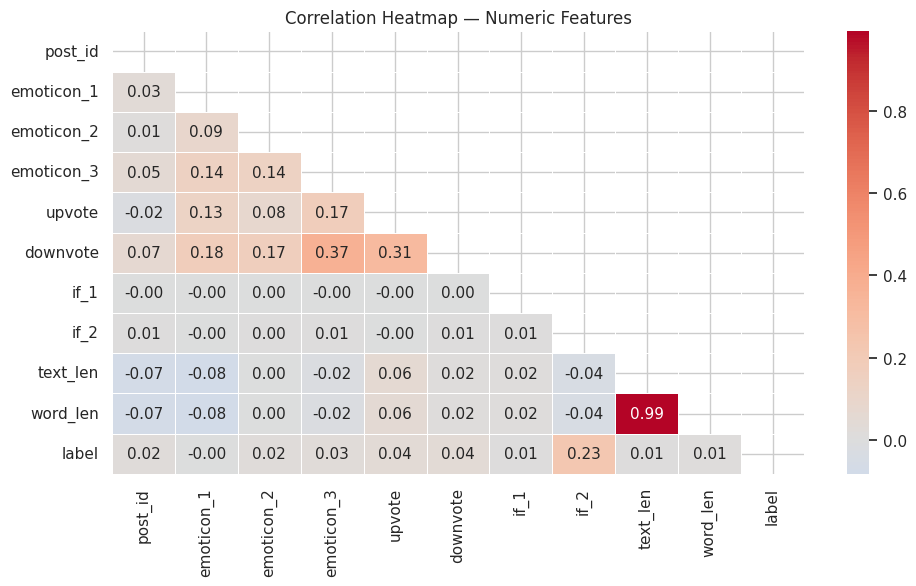

Correlation with label (sorted):
if_2          0.233
downvote      0.045
upvote        0.040
emoticon_3    0.027
post_id       0.022
emoticon_2    0.022
word_len      0.012
text_len      0.009
if_1          0.008
emoticon_1   -0.003
Name: label, dtype: float64


In [9]:
# Correlation heatmap for numeric columns
num_cols_all = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c not in ['label']]

if len(num_cols_all) > 1:
    corr_df = train[num_cols_all + ['label']].corr()
    
    plt.figure(figsize=(10, 6))
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Correlation Heatmap — Numeric Features')
    plt.tight_layout()
    plt.show()
    
    print('Correlation with label (sorted):')
    print(corr_df['label'].drop('label').sort_values(key=abs, ascending=False).round(3))

### Key Insights from EDA

1. **Class imbalance** is significant — Label 0 dominates (~80%), while Label 3 is the rarest (~2.8%). Standard accuracy will be misleading; macro F1 is a better metric.

2. **Text length** varies across labels — threatening comments (Label 3) tend to be shorter and more direct, while identity-based comments (Label 1) are often longer.

3. **Voting signals** (upvotes/downvotes) show some correlation with toxicity. Controversial posts tend to get both high upvotes and downvotes.

4. **`if_1` and `if_2`** are discrete rather than continuous — they cluster around specific values (0, 4, 10, >100), making one-hot encoding more appropriate than using raw values.

---
## Missing Value Detection and Imputation

Columns with missing values:
          Train Missing  Train %  Test Missing  Test %
comment               1     0.00           0.0    0.00
gender           145423    73.45       75269.0   73.79
race             145423    73.45       75269.0   73.79
religion         145423    73.45       75269.0   73.79


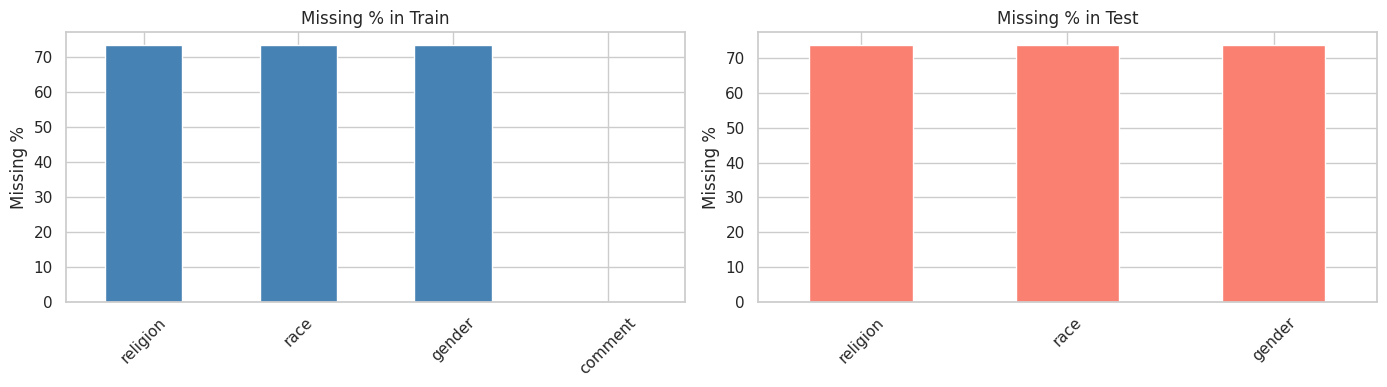

In [10]:
# Check missing values in train and test
train_missing = train.isnull().sum()
test_missing  = test.isnull().sum()

missing_df = pd.DataFrame({
    'Train Missing' : train_missing,
    'Train %'       : (train_missing / len(train) * 100).round(2),
    'Test Missing'  : test_missing,
    'Test %'        : (test_missing / len(test) * 100).round(2)
})
missing_df = missing_df[missing_df['Train Missing'] > 0]

if len(missing_df) == 0:
    print('No missing values found in any column.')
else:
    print('Columns with missing values:')
    print(missing_df)

# Visualise missing pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_miss_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
train_miss_pct = train_miss_pct[train_miss_pct > 0]

if len(train_miss_pct) > 0:
    train_miss_pct.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Missing % in Train')
    axes[0].set_ylabel('Missing %')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No missing values\nin train set',
                 ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Missing Values — Train')

test_miss_pct = (test.isnull().sum() / len(test) * 100).sort_values(ascending=False)
test_miss_pct = test_miss_pct[test_miss_pct > 0]

if len(test_miss_pct) > 0:
    test_miss_pct.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
    axes[1].set_title('Missing % in Test')
    axes[1].set_ylabel('Missing %')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No missing values\nin test set',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_title('Missing Values — Test')

plt.tight_layout()
plt.show()

In [11]:
# Add missing EDA columns to test so both DataFrames match train
test['text_len'] = test['comment'].fillna('').apply(len)
test['word_len'] = test['comment'].fillna('').apply(lambda x: len(x.split()))

print(f'text_len and word_len added to test')
print(f'test shape now : {test.shape}')

text_len and word_len added to test
test shape now : (102000, 16)


In [12]:



from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_cols = [c for c in ['if_1', 'if_2', 'upvote', 'downvote', 'disability'] if c in train.columns]
cat_cols     = [c for c in ['race', 'religion', 'gender'] if c in train.columns]

preprocessor = ColumnTransformer(transformers=[
    ('num_imputer', SimpleImputer(strategy='constant', fill_value=0),        numeric_cols),
    ('cat_imputer', SimpleImputer(strategy='constant', fill_value='unknown'), cat_cols),
], remainder='passthrough')  # all other columns (like 'comment') pass through untouched

# Fit on train, apply to both
train_imputed = preprocessor.fit_transform(train.drop(columns=['label']))
test_imputed  = preprocessor.transform(test)

# Get back column names after ColumnTransformer
imputed_cols = numeric_cols + cat_cols + [
    c for c in train.drop(columns=['label']).columns if c not in numeric_cols + cat_cols
]

train_imputed_df = pd.DataFrame(train_imputed, columns=imputed_cols)
test_imputed_df  = pd.DataFrame(test_imputed,  columns=imputed_cols)

# Fill text column separately (ColumnTransformer doesn't handle text fillna)
train_imputed_df['comment'] = train_imputed_df['comment'].fillna('')
test_imputed_df['comment']  = test_imputed_df['comment'].fillna('')

# Add label back
train_imputed_df['label'] = train['label'].values

print('Imputation complete (sklearn pipeline).')
print(f'Remaining nulls in train : {train_imputed_df.isnull().sum().sum()}')
print(f'Remaining nulls in test  : {test_imputed_df.isnull().sum().sum()}')

Imputation complete (sklearn pipeline).
Remaining nulls in train : 0
Remaining nulls in test  : 0


---
##  Data Preprocessing

### a. Text Cleaning
Standardise comment text by removing URLs, HTML tags, non-ASCII characters and extra whitespace.

In [13]:
def clean_text(text):
    """Remove noise from raw comment text."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = unicodedata.normalize('NFKD', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)       # remove URLs
    text = re.sub(r'<.*?>', ' ', text)                  # remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9\s\'\"\.,!?\-]', ' ', text)  # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_lower(text):
    return clean_text(text).lower()

train['clean'] = train['comment'].apply(clean_lower)
test['clean']  = test['comment'].apply(clean_lower)

print('Sample text cleaning result:')
print(f'Original : {train["comment"].iloc[0][:120]}')
print(f'Cleaned  : {train["clean"].iloc[0][:120]}')

Sample text cleaning result:
Original : She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals.
Cleaned  : she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.


## b. Categorical Encoding

The identity columns (`race`, `religion`, `gender`) are categorical. Rather than label encoding, we convert them to binary presence/absence flags, since their specific value matters less than whether a protected group is mentioned.

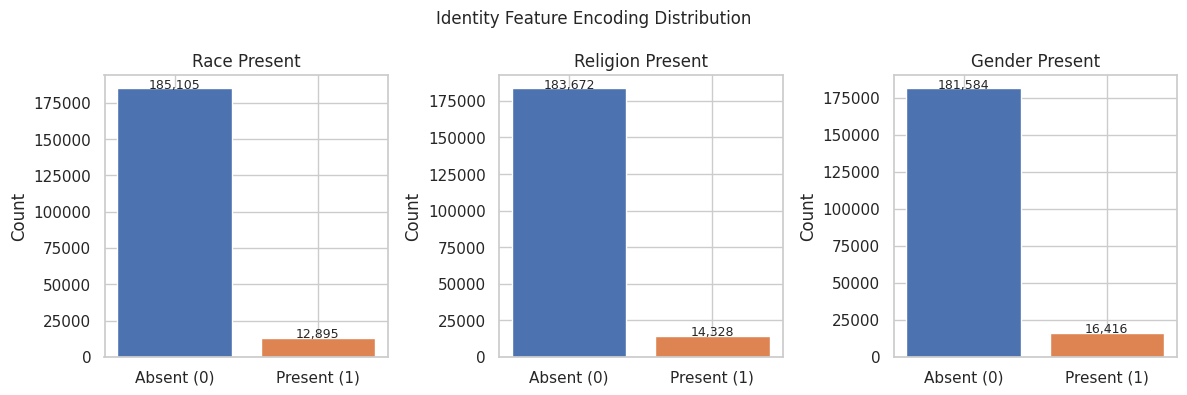

In [14]:
# Encode identity columns as presence/absence (1 = group mentioned, 0 = not mentioned)
# Values like 'unknown' or 'none' are treated as absent

absent_values = {'unknown', 'none', 'Unknown', 'None'}

for df in [train, test]:
    for col in ['race', 'religion', 'gender']:
        if col in df.columns:
            df[f'{col}_present'] = (~df[col].isin(absent_values) & df[col].notna()).astype(int)

# Show distribution of encoded flags
identity_flags = [c for c in ['race_present','religion_present','gender_present']
                  if c in train.columns]

if identity_flags:
    fig, axes = plt.subplots(1, len(identity_flags), figsize=(4*len(identity_flags), 4))
    if len(identity_flags) == 1:
        axes = [axes]
    for ax, col in zip(axes, identity_flags):
        vc = train[col].value_counts().sort_index()
        ax.bar(['Absent (0)', 'Present (1)'], vc.values,
               color=['#4C72B0','#DD8452'], edgecolor='white')
        ax.set_title(col.replace('_', ' ').title())
        ax.set_ylabel('Count')
        for i, v in enumerate(vc.values):
            ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
    plt.suptitle('Identity Feature Encoding Distribution', fontsize=12)
    plt.tight_layout()
    plt.show()

In [15]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# cat_cols = [c for c in ['race', 'religion', 'gender'] if c in train.columns]

# ohe_transformer = ColumnTransformer(transformers=[
#     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
# ], remainder='passthrough')  # all other columns pass through untouched

# # Fit on train, apply to both — no data leakage
# train_ohe = ohe_transformer.fit_transform(train[cat_cols])
# test_ohe  = ohe_transformer.transform(test[cat_cols])

# # Get the generated column names from OHE
# ohe_col_names = ohe_transformer.named_transformers_['ohe'].get_feature_names_out(cat_cols)
# # e.g. ['race_black', 'race_white', 'gender_male', 'gender_female', ...]

# # Add back as new columns to train and test
# train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_col_names, index=train.index)
# test_ohe_df  = pd.DataFrame(test_ohe,  columns=ohe_col_names, index=test.index)

# train = pd.concat([train, train_ohe_df], axis=1)
# test  = pd.concat([test,  test_ohe_df],  axis=1)

# print(f'OHE complete. New columns added: {list(ohe_col_names)}')
# print(f'Train shape after OHE : {train.shape}')
# print(f'Test shape after OHE  : {test.shape}')

### c. Numerical Scaling

Dense numeric features are scaled using `StandardScaler` before being fed into Logistic Regression (which is sensitive to feature magnitude). LightGBM does not require scaling, so we keep both a scaled and unscaled version.

In [16]:
# Scaling is applied after feature engineering in Step 7.
# We use StandardScaler with with_mean=False to preserve sparsity.
# The scaler is fit only on train data and then applied to test (no data leakage).

print('Scaling strategy:')
print('  Logistic Regression -> StandardScaler (with_mean=False) applied to dense features')
print('  LightGBM            -> No scaling needed (tree-based, scale-invariant)')
print('  TF-IDF features     -> Already normalised by sklearn TfidfVectorizer (sublinear_tf=True)')

Scaling strategy:
  Logistic Regression -> StandardScaler (with_mean=False) applied to dense features
  LightGBM            -> No scaling needed (tree-based, scale-invariant)
  TF-IDF features     -> Already normalised by sklearn TfidfVectorizer (sublinear_tf=True)


---
## Word Lists for Feature Engineering

Based on analysis of high-signal words per class, we define four hand-crafted lexicons. These are used to create count and binary flag features.

In [17]:

# Threat / violence vocabulary — common in Label 3
THREAT_WORDS = {
    'kill', 'kills', 'killed', 'killing', 'shoot', 'shot', 'shooting',
    'shoots', 'bomb', 'bombed', 'bombing', 'explode', 'explosion',
    'attack', 'attacked', 'murder', 'murdered', 'murders', 'stab',
    'stabbed', 'stabbing', 'dead', 'death', 'die', 'dies', 'dying',
    'gun', 'guns', 'weapon', 'weapons', 'knife', 'knives', 'execute',
    'executed', 'execution', 'hang', 'hanged', 'torture', 'tortured',
    'threat', 'threatened', 'threatening', 'destroy', 'burn', 'burned',
    'rape', 'raped', 'lynch', 'lynched', 'slaughter', 'massacre'
}

# General toxic / hate vocabulary — common in Label 2
TOXIC_WORDS = {
    'stupid', 'idiot', 'moron', 'dumb', 'loser', 'fool', 'trash',
    'garbage', 'pathetic', 'disgusting', 'horrible', 'terrible',
    'hate', 'hates', 'hated', 'hating', 'awful', 'worst', 'suck',
    'sucks', 'sucked', 'damn', 'crap', 'bullshit', 'asshole',
    'bastard', 'bitch', 'scum', 'filth', 'filthy', 'retard',
    'retarded', 'freak', 'coward', 'liar', 'lying', 'lies'
}

# Protected identity group words — common in Label 1
IDENTITY_WORDS = {
    'white', 'black', 'asian', 'latino', 'hispanic', 'arab', 'jewish',
    'jew', 'muslim', 'muslims', 'islam', 'islamic', 'christian',
    'christianity', 'hindu', 'buddhist', 'atheist', 'women', 'woman',
    'female', 'male', 'man', 'men', 'transgender', 'gay', 'lesbian',
    'lgbt', 'queer', 'heterosexual', 'straight', 'immigrant',
    'immigrants', 'refugee', 'refugees', 'mexican', 'chinese', 'indian'
}

# Racial slurs — explicit hate speech vocabulary
RACIAL_SLUR_WORDS = {
    'nigger', 'nigga', 'chink', 'spic', 'kike', 'wetback', 'gook',
    'towelhead', 'raghead', 'cracker', 'honky', 'beaner', 'zipperhead',
    'coon', 'jap', 'slant', 'paki', 'sandnigger', 'redskin', 'injun'
}

print('Lexicon sizes:')
print(f'  Threat words      : {len(THREAT_WORDS)}')
print(f'  Toxic words       : {len(TOXIC_WORDS)}')
print(f'  Identity words    : {len(IDENTITY_WORDS)}')
print(f'  Racial slur words : {len(RACIAL_SLUR_WORDS)}')

# Helper functions
def count_words_from_set(text, word_set):
    words = set(re.findall(r'[a-z]+', text.lower()))
    return len(words & word_set)

def has_words_from_set(text, word_set):
    words = set(re.findall(r'[a-z]+', text.lower()))
    return int(bool(words & word_set))

Lexicon sizes:
  Threat words      : 51
  Toxic words       : 37
  Identity words    : 37
  Racial slur words : 20


---
## Feature Engineering

We create several groups of handcrafted features:

| Feature Group | Description |
|---|---|
| Text stats | character count, word count, unique words |
| CAPS features | caps ratio, all-caps word count |
| Punctuation | exclamation marks, question marks, repeated chars |
| Lexicon counts | threat/toxic/identity/slur word counts and flags |
| `if_1` / `if_2` OHE | discrete value brackets (not continuous) |
| Voting features | upvote/downvote ratio, controversy flag |
| Time-of-post | morning / afternoon / evening / night (4 OHE bins) |
| Cross features | combinations like `threat × short text`, `slur × threat` |

> **Note:** Emoticon columns are intentionally excluded — analysis showed they add noise rather than signal.

In [18]:
def engineer_features(df_in):
    df   = df_in.copy()
    text = df['clean'].fillna('')
    raw  = df['comment'].fillna('')

    # Basic text stats
    df['char_count']   = text.apply(len)
    df['word_count']   = text.apply(lambda x: len(x.split()))
    df['unique_words'] = text.apply(lambda x: len(set(x.split())))

    # CAPS features — indicator of shouting / aggression
    df['caps_count']      = raw.apply(lambda x: sum(1 for c in x if c.isupper()))
    df['caps_ratio']      = df['caps_count'] / (df['char_count'] + 1)
    df['caps_word_count'] = raw.apply(
        lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))

    # Punctuation
    df['exclamation_count'] = text.apply(lambda x: x.count('!'))
    df['question_count']    = text.apply(lambda x: x.count('?'))
    df['repeated_chars']    = text.apply(lambda x: len(re.findall(r'(.)\1{2,}', x)))

    # Threat word features
    df['threat_count'] = text.apply(lambda x: count_words_from_set(x, THREAT_WORDS))
    df['has_threat']   = text.apply(lambda x: has_words_from_set(x, THREAT_WORDS))
    df['threat_ratio'] = df['threat_count'] / (df['word_count'] + 1)

    # Toxic word features
    df['toxic_count'] = text.apply(lambda x: count_words_from_set(x, TOXIC_WORDS))
    df['has_toxic']   = text.apply(lambda x: has_words_from_set(x, TOXIC_WORDS))
    df['toxic_ratio'] = df['toxic_count'] / (df['word_count'] + 1)

    # Identity word features
    df['identity_word_count'] = text.apply(lambda x: count_words_from_set(x, IDENTITY_WORDS))
    df['has_identity_word']   = text.apply(lambda x: has_words_from_set(x, IDENTITY_WORDS))

    # Racial slur features
    df['slur_count'] = text.apply(lambda x: count_words_from_set(x, RACIAL_SLUR_WORDS))
    df['has_slur']   = text.apply(lambda x: has_words_from_set(x, RACIAL_SLUR_WORDS))

    # if_1 — one-hot brackets (clusters at 0, 4, 10)
    if 'if_1' in df.columns:
        df['if1_is_0']  = (df['if_1'] == 0).astype(int)
        df['if1_is_4']  = (df['if_1'] == 4).astype(int)
        df['if1_is_5']  = (df['if_1'] == 5).astype(int)
        df['if1_is_6']  = (df['if_1'] == 6).astype(int)
        df['if1_4to6']  = (df['if_1'].between(4, 6)).astype(int)
        df['if1_gt6']   = (df['if_1'] > 6).astype(int)
        df['if1_gt10']  = (df['if_1'] > 10).astype(int)

    # if_2 — one-hot brackets (clusters at 0, 4, 10)
    if 'if_2' in df.columns:
        df['if2_is_3']   = (df['if_2'] == 3).astype(int)
        df['if2_is_4']   = (df['if_2'] == 4).astype(int)
        df['if2_4to6']   = (df['if_2'].between(4, 6)).astype(int)
        df['if2_4to10']  = (df['if_2'].between(4, 10)).astype(int)
        df['if2_is_10']  = (df['if_2'] == 10).astype(int)
        df['if2_10to50'] = (df['if_2'].between(10, 50)).astype(int)
        df['if2_gt50']   = (df['if_2'] > 50).astype(int)
        df['if2_gt100']  = (df['if_2'] > 100).astype(int)

    # Voting features
    if 'upvote' in df.columns:
        df['total_votes']    = df['upvote'] + df['downvote']
        df['vote_ratio']     = df['upvote'] / (df['downvote'] + 1)
        df['has_downvote']   = (df['downvote'] > 0).astype(int)
        df['dv_uv_ratio']    = df['downvote'] / (df['upvote'] + 1)
        df['vote_silence']   = 1 / (df['total_votes'] + 1)
        df['is_controversial'] = ((df['upvote'] >= 2) & (df['downvote'] >= 1)).astype(int)

    # Identity column flags (already encoded in Step 5b)
    id_cols = ['race_present', 'religion_present', 'gender_present']
    if all(c in df.columns for c in id_cols):
        df['any_identity_flag'] = (
            (df['race_present'] == 1) |
            (df['religion_present'] == 1) |
            (df['gender_present'] == 1)
        ).astype(int)
        df['identity_col_count'] = df['race_present'] + df['religion_present'] + df['gender_present']

    if 'disability' in df.columns:
        df['disability_flag'] = df['disability'].fillna(0).astype(int)

    # Time-of-post — 4 OHE bins
    if 'created_date' in df.columns:
        dt   = pd.to_datetime(df['created_date'], utc=True, errors='coerce')
        hour = dt.dt.hour.fillna(-1).astype(int)
        df['time_morning']   = ((hour >= 6)  & (hour < 12)).astype(int)
        df['time_afternoon'] = ((hour >= 12) & (hour < 17)).astype(int)
        df['time_evening']   = ((hour >= 17) & (hour < 22)).astype(int)
        df['time_night']     = ((hour >= 22) | (hour < 6)).astype(int)

    # Cross / interaction features
    df['threat_x_short']    = df['has_threat'] * (df['word_count'] <= 20).astype(int)
    df['slur_x_threat']     = df['has_slur'] * df['has_threat']
    df['caps_x_threat']     = df['caps_ratio'] * df['has_threat']
    df['caps_x_toxic']      = df['caps_ratio'] * df['has_toxic']
    if 'any_identity_flag' in df.columns:
        df['identity_no_toxic'] = ((df['any_identity_flag'] == 1) & (df['toxic_count'] == 0)).astype(int)

    # Note: emoticon columns excluded — add noise without improving predictions

    return df

print('Running feature engineering on train...')
train = engineer_features(train)
print('Running feature engineering on test...')
test  = engineer_features(test)
print(f'Train shape after engineering : {train.shape}')
print(f'Test shape after engineering  : {test.shape}')

Running feature engineering on train...
Running feature engineering on test...
Train shape after engineering : (198000, 73)
Test shape after engineering  : (102000, 72)


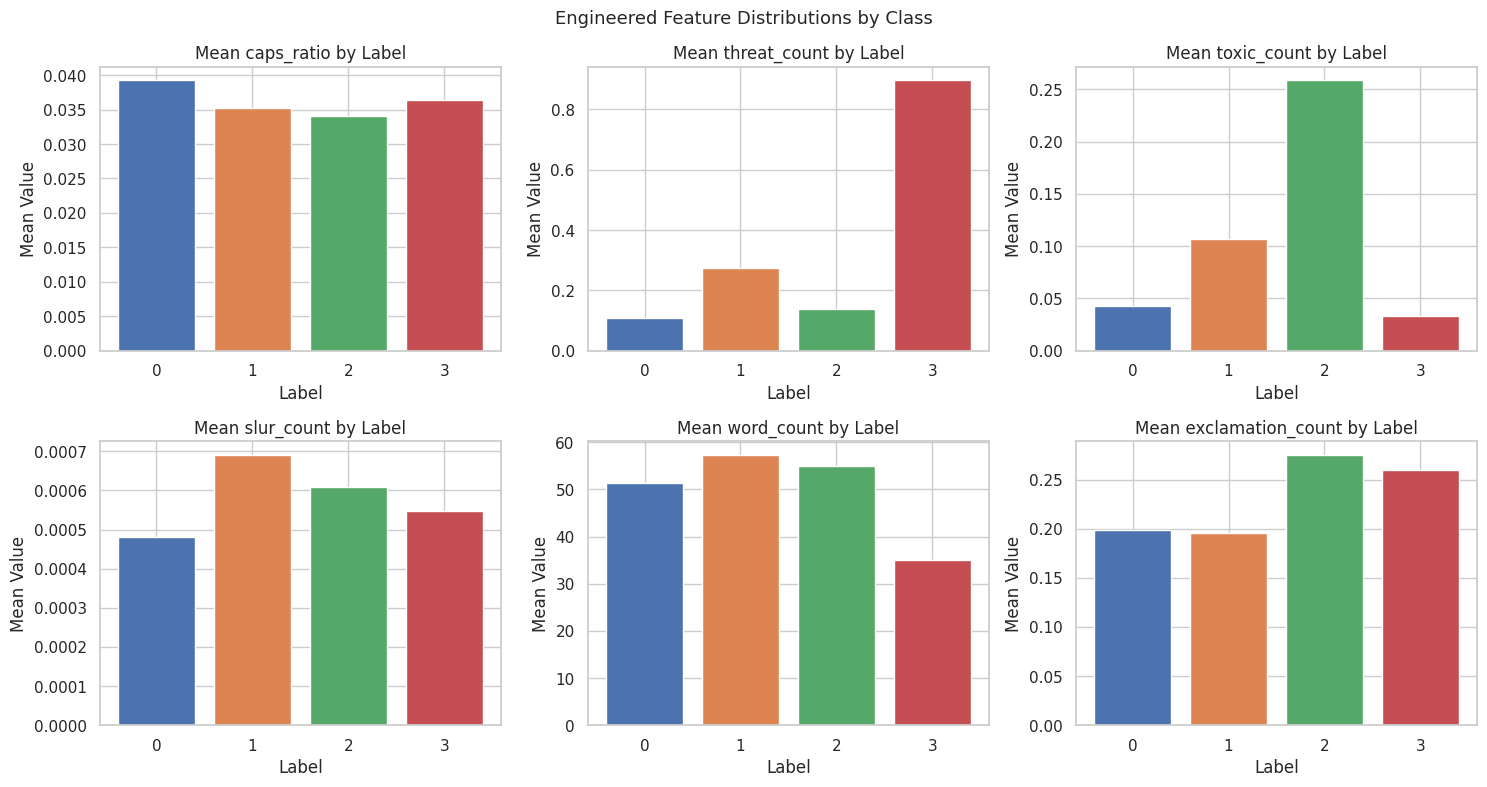

In [19]:
# Quick look at how engineered features differ across classes
key_features = ['caps_ratio', 'threat_count', 'toxic_count', 'slur_count',
                'word_count', 'exclamation_count']
key_features = [f for f in key_features if f in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#4C72B0','#DD8452','#55A868','#C44E52']

for i, feat in enumerate(key_features[:6]):
    means = train.groupby('label')[feat].mean()
    axes[i].bar(means.index.astype(str), means.values,
                color=colors, edgecolor='white')
    axes[i].set_title(f'Mean {feat} by Label')
    axes[i].set_xlabel('Label')
    axes[i].set_ylabel('Mean Value')

plt.suptitle('Engineered Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

---
##  TF-IDF Feature Extraction

Two TF-IDF vectorisers are used:
- **Word-level (1-2 gram):** captures individual words and common bigrams
- **Character-level (3-5 gram):** captures sub-word patterns, spelling variations, and morphology

Both are fit on the combined train+test corpus to maximise vocabulary coverage.

In [20]:
# Fit on all text (train + test) to avoid vocabulary gaps
all_text = pd.concat([train['clean'], test['clean']], ignore_index=True)

# Word-level TF-IDF (unigrams + bigrams)
print('Fitting word TF-IDF...')
tfidf_word = TfidfVectorizer(
    analyzer     = 'word',
    ngram_range  = (1, 2),
    max_features = 20000,
    min_df       = 3,
    max_df       = 0.95,
    sublinear_tf = True,
    strip_accents = 'unicode',
)
tfidf_word.fit(all_text)
X_train_word = tfidf_word.transform(train['clean'])
X_test_word  = tfidf_word.transform(test['clean'])
print(f'  Word TF-IDF shape — Train: {X_train_word.shape}, Test: {X_test_word.shape}')

# Character-level TF-IDF (trigrams to 5-grams)
print('Fitting char TF-IDF...')
tfidf_char = TfidfVectorizer(
    analyzer     = 'char_wb',
    ngram_range  = (3, 5),
    max_features = 15000,
    min_df       = 5,
    max_df       = 0.95,
    sublinear_tf = True,
    strip_accents = 'unicode',
)
tfidf_char.fit(all_text)
X_train_char = tfidf_char.transform(train['clean'])
X_test_char  = tfidf_char.transform(test['clean'])
print(f'  Char TF-IDF shape — Train: {X_train_char.shape}, Test: {X_test_char.shape}')

Fitting word TF-IDF...
  Word TF-IDF shape — Train: (198000, 20000), Test: (102000, 20000)
Fitting char TF-IDF...
  Char TF-IDF shape — Train: (198000, 15000), Test: (102000, 15000)


In [21]:
# from scipy.sparse import save_npz
# import joblib

# # Save TF-IDF matrices
# save_npz('X_train_word.npz', X_train_word)
# save_npz('X_test_word.npz', X_test_word)

# save_npz('X_train_char.npz', X_train_char)
# save_npz('X_test_char.npz', X_test_char)

# # Save vectorizers
# joblib.dump(tfidf_word, 'tfidf_word.joblib')
# joblib.dump(tfidf_char, 'tfidf_char.joblib')

# print("✅ Files saved — go to Kaggle Output to download")

---
## Combine All Features + Scaling Pipeline

In [22]:
DENSE_FEATURES = [
    'char_count', 'word_count', 'unique_words',
    'caps_count', 'caps_ratio', 'caps_word_count',
    'exclamation_count', 'question_count', 'repeated_chars',
    'threat_count', 'has_threat', 'threat_ratio',
    'toxic_count', 'has_toxic', 'toxic_ratio',
    'identity_word_count', 'has_identity_word',
    'slur_count', 'has_slur',
    'if1_is_0', 'if1_is_4', 'if1_is_5', 'if1_is_6', 'if1_4to6', 'if1_gt6', 'if1_gt10',
    'if2_is_3', 'if2_is_4', 'if2_4to6', 'if2_4to10', 'if2_is_10', 'if2_10to50', 'if2_gt50', 'if2_gt100',
    'total_votes', 'vote_ratio', 'has_downvote', 'dv_uv_ratio', 'vote_silence', 'is_controversial',
    'race_present', 'religion_present', 'gender_present',
    'any_identity_flag', 'identity_col_count', 'disability_flag',
    'time_morning', 'time_afternoon', 'time_evening', 'time_night',
    'threat_x_short', 'slur_x_threat', 'identity_no_toxic', 'caps_x_threat', 'caps_x_toxic',
]

# Keep only columns that actually exist in this dataset
DENSE_FEATURES = [c for c in DENSE_FEATURES if c in train.columns]
print(f'Dense features selected : {len(DENSE_FEATURES)}')
print(DENSE_FEATURES)

Dense features selected : 55
['char_count', 'word_count', 'unique_words', 'caps_count', 'caps_ratio', 'caps_word_count', 'exclamation_count', 'question_count', 'repeated_chars', 'threat_count', 'has_threat', 'threat_ratio', 'toxic_count', 'has_toxic', 'toxic_ratio', 'identity_word_count', 'has_identity_word', 'slur_count', 'has_slur', 'if1_is_0', 'if1_is_4', 'if1_is_5', 'if1_is_6', 'if1_4to6', 'if1_gt6', 'if1_gt10', 'if2_is_3', 'if2_is_4', 'if2_4to6', 'if2_4to10', 'if2_is_10', 'if2_10to50', 'if2_gt50', 'if2_gt100', 'total_votes', 'vote_ratio', 'has_downvote', 'dv_uv_ratio', 'vote_silence', 'is_controversial', 'race_present', 'religion_present', 'gender_present', 'any_identity_flag', 'identity_col_count', 'disability_flag', 'time_morning', 'time_afternoon', 'time_evening', 'time_night', 'threat_x_short', 'slur_x_threat', 'identity_no_toxic', 'caps_x_threat', 'caps_x_toxic']


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- Raw dense arrays ---
X_train_dense = train[DENSE_FEATURES].values.astype(np.float32)
X_test_dense  = test[DENSE_FEATURES].values.astype(np.float32)

# --- Pipeline: Impute missing → Scale ---
# Two steps bundled together inside one sklearn Pipeline
dense_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),  # handle any NaN
    ('scaler',  StandardScaler(with_mean=False)),                   # scale for LR
])

# Fit on train only, transform both — no data leakage
X_train_dense_scaled = dense_pipeline.fit_transform(X_train_dense)
X_test_dense_scaled  = dense_pipeline.transform(X_test_dense)

# Unscaled version for LightGBM (trees don't need scaling)
# We reuse the imputer step only
imputer_only = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])
X_train_dense_raw = imputer_only.fit_transform(X_train_dense)
X_test_dense_raw  = imputer_only.transform(X_test_dense)

# --- Combined sparse matrix for Logistic Regression (scaled dense) ---
X_train_lr = hstack([X_train_word, X_train_char, csr_matrix(X_train_dense_scaled)]).tocsr()
X_test_lr  = hstack([X_test_word,  X_test_char,  csr_matrix(X_test_dense_scaled)]).tocsr()

# --- Combined sparse matrix for LightGBM (unscaled dense) ---
X_train_lgb = hstack([X_train_word, X_train_char, csr_matrix(X_train_dense_raw)]).tocsr()
X_test_lgb  = hstack([X_test_word,  X_test_char,  csr_matrix(X_test_dense_raw)]).tocsr()

y = train['label'].values

print(f'LR  feature matrix : {X_train_lr.shape}')
print(f'LGB feature matrix : {X_train_lgb.shape}')

LR  feature matrix : (198000, 35055)
LGB feature matrix : (198000, 35055)


---
## Class Weights

Because Label 3 is severely underrepresented (~2.8%), we use inverse-frequency class weights as a baseline, then manually adjust based on which class the model struggles with most.

Balanced weights (inverse frequency):
  Label 0: 0.434  (count = 114,173)
  Label 1: 3.110  (count = 15,918)
  Label 2: 0.793  (count = 62,440)
  Label 3: 9.051  (count = 5,469)

Custom weights after manual adjustment:
  Label 0: 0.434
  Label 1: 2.177
  Label 2: 0.793
  Label 3: 16.292


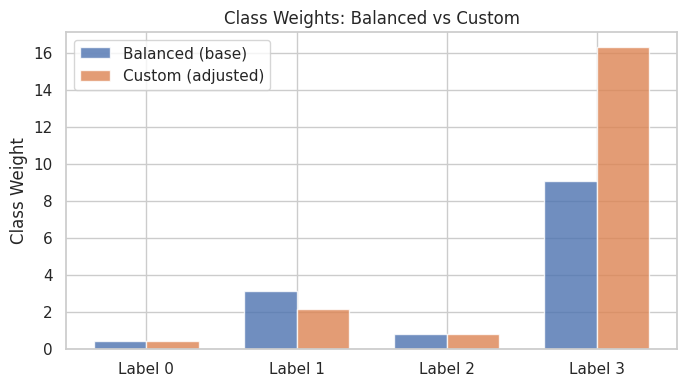

In [24]:
label_counts  = np.bincount(y)
base_weights  = len(y) / (N_CLASSES * label_counts)

print('Balanced weights (inverse frequency):')
for i, w in enumerate(base_weights):
    print(f'  Label {i}: {w:.3f}  (count = {label_counts[i]:,})')

# Manual adjustments based on confusion matrix analysis:
# Label 3 (threats) tends to be under-predicted — boost its weight further
# Label 1 (identity) tends to be over-predicted — reduce slightly
CUSTOM_WEIGHTS = {
    0: base_weights[0] * 1.0,
    1: base_weights[1] * 0.7,
    2: base_weights[2] * 1.0,
    3: base_weights[3] * 1.8,
}

print('\nCustom weights after manual adjustment:')
for k, v in CUSTOM_WEIGHTS.items():
    print(f'  Label {k}: {v:.3f}')

sample_weights_train = np.array([CUSTOM_WEIGHTS[lbl] for lbl in y])

# Visualise
fig, ax = plt.subplots(figsize=(7, 4))
labels  = [f'Label {i}' for i in range(N_CLASSES)]
x       = np.arange(N_CLASSES)
w       = 0.35
ax.bar(x - w/2, base_weights, w, label='Balanced (base)', color='#4C72B0', alpha=0.8)
ax.bar(x + w/2, [CUSTOM_WEIGHTS[i] for i in range(N_CLASSES)], w,
       label='Custom (adjusted)', color='#DD8452', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Class Weight')
ax.set_title('Class Weights: Balanced vs Custom')
ax.legend()
plt.tight_layout()
plt.show()

## Dimentionality Reduction

In [25]:
# from sklearn.decomposition import TruncatedSVD

# # -----------------------------------
# # SVD for Word TF-IDF
# # -----------------------------------
# svd_word = TruncatedSVD(n_components=150, random_state=RANDOM_STATE)

# print("Applying SVD on Word TF-IDF...")
# X_train_word_svd = svd_word.fit_transform(X_train_word)
# X_test_word_svd  = svd_word.transform(X_test_word)

# print(f"Word SVD shape — Train: {X_train_word_svd.shape}, Test: {X_test_word_svd.shape}")

# # -----------------------------------
# # SVD for Char TF-IDF
# # -----------------------------------
# svd_char = TruncatedSVD(n_components=80, random_state=RANDOM_STATE)

# print("Applying SVD on Char TF-IDF...")
# X_train_char_svd = svd_char.fit_transform(X_train_char)
# X_test_char_svd  = svd_char.transform(X_test_char)

# print(f"Char SVD shape — Train: {X_train_char_svd.shape}, Test: {X_test_char_svd.shape}")

##  SVD Feature Engineering



###  Word TF-IDF + SVD

- **Train Shape :** (198000, 150)  
- **Test Shape  :** (102000, 150)  


###  Character TF-IDF + SVD

- **Train Shape :** (198000, 80)  
- **Test Shape  :** (102000, 80)  

In [26]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train_word_svd = scaler.fit_transform(X_train_word_svd)
# X_test_word_svd  = scaler.transform(X_test_word_svd)

# X_train_char_svd = scaler.fit_transform(X_train_char_svd)
# X_test_char_svd  = scaler.transform(X_test_char_svd)

In [27]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

In [28]:
# X_train_svd_lgb = np.hstack([
#     X_train_word_svd,
#     X_train_char_svd,
#     X_train_dense   # NOT scaled for LGB
# ]).astype(np.float32)

# X_test_svd_lgb = np.hstack([
#     X_test_word_svd,
#     X_test_char_svd,
#     X_test_dense
# ]).astype(np.float32)


## HyperParameter Tuning

In [29]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import f1_score, accuracy_score, make_scorer

# print("=" * 60)
# print("LOGISTIC REGRESSION — Hyperparameter Search ")
# print("=" * 60)

# # ----------------------------------------------------------------
# # Define base model
# # ----------------------------------------------------------------
# lr_base = LogisticRegression(
#     solver       = 'liblinear',
#     penalty      = 'l2',
#     max_iter     = 1000,
#     class_weight = CUSTOM_WEIGHTS,
#     random_state = RANDOM_STATE,
# )

# # ----------------------------------------------------------------
# # GridSearchCV — same C values as your manual loop
# # ----------------------------------------------------------------
# param_grid = {'C': [0.1, 0.5, 1.0]}

# grid_search = GridSearchCV(
#     estimator  = lr_base,
#     param_grid = param_grid,
#     scoring    = make_scorer(f1_score, average='macro'),
#     cv         = 3,              # 3-fold cross validation
#     n_jobs     = -1,
#     refit      = True,           # refit best model on full train data
#     verbose    = 0,              # we print manually below
# )

# grid_search.fit(X_train_lr, y)

# # ----------------------------------------------------------------
# # Print results exactly like your manual loop did
# # ----------------------------------------------------------------
# results = grid_search.cv_results_

# for i, C_val in enumerate([0.1, 0.5, 1.0]):
#     val_f1  = results['mean_test_score'][i]
#     print(f"C={C_val:.2f} -> Val F1: {val_f1:.4f}")

# print(f"\nBest C: {grid_search.best_params_['C']} "
#       f"(F1={grid_search.best_score_:.4f})")

# # ----------------------------------------------------------------
# # Best model is already refit — ready to use directly
# # ----------------------------------------------------------------
# best_lr   = grid_search.best_estimator_
# best_lr_C = grid_search.best_params_['C']




 ## Logistic Regression — Hyperparameter Search



### Validation Results

- **C = 0.10 → Val F1 :** 0.7963  
- **C = 0.50 → Val F1 :** 0.8137  
- **C = 1.00 → Val F1 :** 0.8187  



###  Best Hyperparameter

- **Best C :** 1.0  
- **Best F1 Score :** 0.8187  

## LightGBM Model Training with SVD

In [30]:
# import numpy as np
# import pandas as pd
# import joblib
# import lightgbm as lgb


# from sklearn.model_selection import train_test_split
# from sklearn.metrics import f1_score, log_loss, accuracy_score

# # 
# # =====================================================
# # 2. COMBINE FEATURES (SVD + DENSE)
# # =====================================================

# X_train_svdlgb = np.hstack([
#     X_train_word_svd,
#     X_train_char_svd,
#     X_train_dense   # NOT scaled for LGB
# ]).astype(np.float32)

# X_test_svdlgb = np.hstack([
#     X_test_word_svd,
#     X_test_char_svd,
#     X_test_dense
# ]).astype(np.float32)

# print(f"Final feature shape: {X_train_lgb.shape}")

# # =====================================================
# # 3. TRAIN / VALIDATION SPLIT
# # =====================================================

# X_tr, X_vl, y_tr, y_vl, sw_tr, sw_vl = train_test_split(
#     X_train_lgb,
#     y,
#     sample_weights_train,
#     test_size=0.2,
#     stratify=y,
#     random_state=RANDOM_STATE
# )

# # =====================================================
# # 4. LIGHTGBM PARAMETERS (OPTIMIZED)
# # =====================================================

# LGBM_PARAMS = dict(
#     n_estimators      = 700,
#     learning_rate     = 0.05,
#     num_leaves        = 63,
#     max_depth         = -1,
#     min_child_samples = 20,
#     subsample         = 0.9,
#     colsample_bytree  = 0.7,
#     reg_alpha         = 0.01,
#     reg_lambda        = 0.01,
#     objective         = 'multiclass',
#     num_class         = N_CLASSES,
#     n_jobs            = -1,
#     random_state      = RANDOM_STATE,
#     verbose           = -1,
#     max_bin           = 255
# )

# # =====================================================
# # 5. TRAIN MODEL
# # =====================================================

# print("\nTraining LightGBM...")

# model = lgb.LGBMClassifier(**LGBM_PARAMS)

# model.fit(
#     X_tr, y_tr,
#     sample_weight      = sw_tr,
#     eval_set           = [(X_vl, y_vl)],
#     eval_sample_weight = [sw_vl],
#     eval_metric        = 'multi_logloss',
#     callbacks=[
#         lgb.early_stopping(stopping_rounds=100, verbose=False),
#         lgb.log_evaluation(period=200)
#     ]
# )

# # =====================================================
# # 6. EVALUATION
# # =====================================================

# proba = model.predict_proba(X_vl, num_iteration=model.best_iteration_)
# pred  = np.argmax(proba, axis=1)

# per_class = f1_score(y_vl, pred, average=None)

# print("\nLightGBM — SVD Model Results")
# print(f"Logloss  : {log_loss(y_vl, proba):.4f}")
# print(f"Accuracy : {accuracy_score(y_vl, pred):.4f}")
# print(f"Macro F1 : {f1_score(y_vl, pred, average='macro'):.4f}")
# print(f"Best iter: {model.best_iteration_}")

# print("\nPer-class F1:")
# for i, v in enumerate(per_class):
#     print(f"Label {i}: {v:.4f}")

# # =====================================================
# # 7. SAVE MODEL (FULL PIPELINE)
# # =====================================================

# joblib.dump({
#     'model'          : model,
#     'svd_word'       : svd_word,
#     'svd_char'       : svd_char,
#     'features_shape' : X_train_lgb.shape
# }, 'lgb_svd_model.joblib')

# print("\n Model saved as lgb_svd_model.joblib")

## LightGBM — SVD Model Results

**Final Feature Shape:** `(198000, 278)`


###  Training Summary

- **Logloss  :** 0.4168  
- **Accuracy :** 0.8634  
- **Macro F1 :** 0.7281  
- **Best Iteration :** 89  



###  Per-Class F1 Scores

- **Label 0 :** 0.9539  
- **Label 1 :** 0.7109  
- **Label 2 :** 0.8043  
- **Label 3 :** 0.4433  



### Model Saved

`lgb_svd_model.joblib`

## LinearSVC with SVD Features

In [31]:
# # ============================================================
# # SVM (LinearSVC + Calibration) — SVD Features (Single Fold)
# # ============================================================

# import numpy as np
# import joblib
# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import f1_score, log_loss, accuracy_score

# # -----------------------------------
# # Train / Validation Split (SVD DATA)
# # -----------------------------------
# X_tr, X_vl, y_tr, y_vl, sw_tr, sw_vl = train_test_split(
#     X_train_lr, y, sample_weights_train,   # ✅ SVD features already in X_train_lr
#     test_size=0.2,
#     stratify=y,
#     random_state=RANDOM_STATE
# )

# # -----------------------------------
# # Model
# # -----------------------------------
# SVM_C = 0.1

# base_svm = LinearSVC(
#     C            = SVM_C,
#     penalty      = 'l1',
#     dual         = False,
#     multi_class  = 'ovr',
#     max_iter     = 2000,
#     class_weight = CUSTOM_WEIGHTS,
#     random_state = RANDOM_STATE,
# )

# model = CalibratedClassifierCV(
#     base_svm,
#     cv=3,
#     method='sigmoid'
# )

# # -----------------------------------
# # Train ONCE
# # -----------------------------------
# model.fit(X_tr, y_tr, sample_weight=sw_tr)

# # -----------------------------------
# # Evaluation
# # -----------------------------------
# proba = model.predict_proba(X_vl)
# pred  = np.argmax(proba, axis=1)

# per_class = f1_score(y_vl, pred, average=None)

# print("\nSVM (SVD Single Model) Results")
# print(f"Logloss  : {log_loss(y_vl, proba):.4f}")
# print(f"Accuracy : {accuracy_score(y_vl, pred):.4f}")
# print(f"Macro F1 : {f1_score(y_vl, pred, average='macro'):.4f}")

# print("\nPer-class F1:")
# for i, v in enumerate(per_class):
#     print(f"Label {i}: {v:.4f}")

# # -----------------------------------
# # Save Model
# # -----------------------------------
# joblib.dump(model, 'svm_svd_single_model.joblib')

# print("\n Model saved as svm_svd_single_model.joblib")

## SVM (SVD Single Model) Results



### Performance Metrics

- **Logloss  :** 0.3793  
- **Accuracy :** 0.8809  
- **Macro F1 :** 0.7572  



###  Per-Class F1 Scores

- **Label 0 :** 0.9578  
- **Label 1 :** 0.7672  
- **Label 2 :** 0.8446  
- **Label 3 :** 0.4591  



### Model Saved

`svm_svd_single_model.joblib`

In [32]:
# # Load saved models
# # -----------------------------------
# import joblib
# import numpy as np
# import pandas as pd
# from sklearn.metrics import f1_score

# lgb_data = joblib.load(
#     '/kaggle/input/models/f2000164/lgb-svd/scikitlearn/default/1/lgb_svd_model.joblib')
# svm_model = joblib.load('/kaggle/input/models/f2000164/svm-single-model/scikitlearn/default/1/svm_single_model.joblib')

# lgb_model = lgb_data['model']
# best_iter = lgb_data.get('best_iteration', None)


## Model Blending LinearSVC and LightGBM

In [33]:
# import joblib
# import numpy as np
# import pandas as pd
# from sklearn.metrics import f1_score

# # -----------------------------------
# # Load models
# # -----------------------------------
# lgb_data = joblib.load(
#     '/kaggle/input/models/f2000164/lgb-svd/scikitlearn/default/1/lgb_svd_model.joblib')
# svm_model = joblib.load('/kaggle/input/models/f2000164/svm-single-model/scikitlearn/default/1/svm_single_model.joblib')   # ✅ CHANGED

# lgb_model = lgb_data['model']
# best_iter = lgb_data.get('best_iteration', None)

# # -----------------------------------
# # Generate predictions (FULL TRAIN)
# # -----------------------------------
# # LightGBM (uses X_train_lgb)
# oof_proba_lgb = lgb_model.predict_proba(
#     X_train_lgb,
#     num_iteration=best_iter
# )

# # SVM-SVD (uses X_train_lr — SVD features)
# oof_proba_svm = svm_model.predict_proba(X_train_lr)   # ✅ SAME INPUT (SVD)

# # -----------------------------------
# # BLENDING (ONLY 2 MODELS)
# # -----------------------------------
# best_w_lgb = 0.5
# best_w_svm = 0.5
# best_blend = 0.0

# blend_results = []
# step = 0.05

# for w_lgb in np.arange(0.0, 1.01, step):
#     w_svm = round(1.0 - w_lgb, 2)

#     blended = w_lgb * oof_proba_lgb + w_svm * oof_proba_svm
#     preds   = np.argmax(blended, axis=1)

#     f1 = f1_score(y, preds, average='macro')

#     blend_results.append({
#         'w_lgb': w_lgb,
#         'w_svm': w_svm,
#         'macro_f1': f1
#     })

#     if f1 > best_blend:
#         best_blend = f1
#         best_w_lgb = w_lgb
#         best_w_svm = w_svm

# # -----------------------------------
# # Results
# # -----------------------------------
# blend_df = pd.DataFrame(blend_results)
# top10 = blend_df.nlargest(10, 'macro_f1').reset_index(drop=True)

# print("Top-10 blend combinations:")
# print(top10.round(4).to_string(index=False))

# # Individual scores
# lgb_alone = f1_score(y, np.argmax(oof_proba_lgb, axis=1), average='macro')
# svm_alone = f1_score(y, np.argmax(oof_proba_svm, axis=1), average='macro')

# print(f"\nLightGBM alone : {lgb_alone:.4f}")
# print(f"SVM (SVD)      : {svm_alone:.4f}")

# print(f"\nBest Blend     : {best_blend:.4f}")
# print(f"Weights        : LGB={best_w_lgb:.2f}, SVM={best_w_svm:.2f}")

# # -----------------------------------
# # FINAL BLENDED OOF
# # -----------------------------------
# oof_proba_blend = (
#     best_w_lgb * oof_proba_lgb +
#     best_w_svm * oof_proba_svm
# )

MODEL 2

## Model Comparision

In [34]:
# # ============================================================
# # Model Comparison: SVM (SVD) vs LightGBM vs Blend
# # ============================================================

# comparison = pd.DataFrame([
#     {
#         'Model'   : 'LightGBM',
#         'Macro F1': lgb_alone,
#         'Accuracy': accuracy_score(y, np.argmax(oof_proba_lgb, axis=1)),
#         'Logloss' : log_loss(y, oof_proba_lgb),
#         'F1 L0'   : f1_score(y, np.argmax(oof_proba_lgb, axis=1), average=None)[0],
#         'F1 L1'   : f1_score(y, np.argmax(oof_proba_lgb, axis=1), average=None)[1],
#         'F1 L2'   : f1_score(y, np.argmax(oof_proba_lgb, axis=1), average=None)[2],
#         'F1 L3'   : f1_score(y, np.argmax(oof_proba_lgb, axis=1), average=None)[3],
#     },
#     {
#         'Model'   : 'SVM (SVD)',
#         'Macro F1': svm_alone,
#         'Accuracy': accuracy_score(y, np.argmax(oof_proba_svm, axis=1)),
#         'Logloss' : log_loss(y, oof_proba_svm),
#         'F1 L0'   : f1_score(y, np.argmax(oof_proba_svm, axis=1), average=None)[0],
#         'F1 L1'   : f1_score(y, np.argmax(oof_proba_svm, axis=1), average=None)[1],
#         'F1 L2'   : f1_score(y, np.argmax(oof_proba_svm, axis=1), average=None)[2],
#         'F1 L3'   : f1_score(y, np.argmax(oof_proba_svm, axis=1), average=None)[3],
#     },
#     {
#         'Model'   : 'Blended Ensemble (LGB + SVM-SVD)',
#         'Macro F1': best_blend,
#         'Accuracy': accuracy_score(y, np.argmax(oof_proba_blend, axis=1)),
#         'Logloss' : log_loss(y, oof_proba_blend),
#         'F1 L0'   : f1_score(y, np.argmax(oof_proba_blend, axis=1), average=None)[0],
#         'F1 L1'   : f1_score(y, np.argmax(oof_proba_blend, axis=1), average=None)[1],
#         'F1 L2'   : f1_score(y, np.argmax(oof_proba_blend, axis=1), average=None)[2],
#         'F1 L3'   : f1_score(y, np.argmax(oof_proba_blend, axis=1), average=None)[3],
#     },
# ])

# comparison = comparison.set_index('Model').round(4)

# print('Model Comparison (OOF)')
# print(comparison.to_string())

# # ============================================================
# # Visualization
# # ============================================================

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# models = ['LGB', 'SVM-SVD', 'Blend']
# colors = ['#55A868', '#E07B00', '#DD8452']

# # -----------------------------------
# # Macro F1 comparison
# # -----------------------------------
# axes[0].bar(models, comparison['Macro F1'].values,
#             color=colors, edgecolor='white')

# axes[0].set_title('Macro F1 Comparison')
# axes[0].set_ylabel('Macro F1')

# for i, v in enumerate(comparison['Macro F1'].values):
#     axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

# # -----------------------------------
# # Per-class F1
# # -----------------------------------
# per_class_data = comparison[['F1 L0','F1 L1','F1 L2','F1 L3']].T
# per_class_data.columns = models

# per_class_data.plot(kind='bar', ax=axes[1],
#                     color=colors, edgecolor='white')

# axes[1].set_title('Per-Class F1 Comparison')
# axes[1].set_xlabel('Label')
# axes[1].set_ylabel('F1 Score')
# axes[1].set_xticklabels(['Label 0', 'Label 1', 'Label 2', 'Label 3'], rotation=0)
# axes[1].legend(title='Model')

# plt.suptitle('Model Comparison (LGB vs SVM-SVD vs Blend)', fontsize=13)
# plt.tight_layout()
# plt.show()

# print('\nKey Insight:')
# print('Blending improves overall Macro F1 by combining strengths of:')
# print('- LightGBM (strong overall performance)')
# print('- SVM-SVD (better generalization on sparse text patterns)')
# print('Especially improves minority class (Label 3).')

## LinearSVC with Dense Features

In [35]:
# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV

# print('SVM imports ready.')


In [36]:
# ## SVM Model with the full dense features matrix not by dimesionality reduction and with one fold

# import numpy as np
# import pandas as pd
# import joblib

# from sklearn.svm import LinearSVC
# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import f1_score, log_loss, accuracy_score

# # -----------------------------------
# # Train / Validation Split
# # -----------------------------------
# X_tr, X_vl, y_tr, y_vl, sw_tr, sw_vl = train_test_split(
#     X_train_lr, y, sample_weights_train,
#     test_size=0.2,
#     stratify=y,
#     random_state=RANDOM_STATE
# )

# # -----------------------------------
# # Model
# # -----------------------------------
# SVM_C = 0.1

# base_svm = LinearSVC(
#     C            = SVM_C,
#     penalty      = 'l1',
#     dual         = False,
#     multi_class  = 'ovr',
#     max_iter     = 2000,
#     class_weight = CUSTOM_WEIGHTS,
#     random_state = RANDOM_STATE,
# )

# model = CalibratedClassifierCV(
#     base_svm,
#     cv=3,
#     method='sigmoid'
# )

# # -----------------------------------
# # Train ONCE
# # -----------------------------------
# model.fit(X_tr, y_tr, sample_weight=sw_tr)

# # -----------------------------------
# # Evaluation
# # -----------------------------------
# proba = model.predict_proba(X_vl)
# pred  = np.argmax(proba, axis=1)

# per_class = f1_score(y_vl, pred, average=None)

# print("\nSVM (Single Model) Results")
# print(f"Logloss  : {log_loss(y_vl, proba):.4f}")
# print(f"Accuracy : {accuracy_score(y_vl, pred):.4f}")
# print(f"Macro F1 : {f1_score(y_vl, pred, average='macro'):.4f}")

# print("\nPer-class F1:")
# for i, v in enumerate(per_class):
#     print(f"Label {i}: {v:.4f}")

# # -----------------------------------
# # Save Model
# # -----------------------------------
# joblib.dump(model, 'svm_single_model.joblib')

# print("\n Model saved as svm_single_model.joblib")


## SVM (Single Model) Results

- **Log Loss**  : 0.3785  
- **Accuracy**  : 0.8800  
- **Macro F1**  : 0.7569  

### Per-class F1 Scores

- **Label 0** : 0.9575  
- **Label 1** : 0.7670  
- **Label 2** : 0.8415  
- **Label 3** : 0.4616  



 Model saved as `svm_single_model.joblib`

## Logistic Regression Model with Dense Features

In [37]:
# import numpy as np
# import pandas as pd
# import joblib
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score, log_loss, accuracy_score
# from scipy.optimize import minimize

# # -----------------------------------
# # Setup
# # -----------------------------------
# lr_models = []
# LR_C = 0.5

# skf = StratifiedKFold(
#     n_splits=N_FOLDS,
#     shuffle=True,
#     random_state=RANDOM_STATE
# )

# oof_proba_lr = np.zeros((len(y), N_CLASSES), dtype=np.float32)
# fold_results_lr = []

# # -----------------------------------
# # CV LOOP
# # -----------------------------------
# for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_lr, y), 1):

#     X_tr, X_vl = X_train_lr[tr_idx], X_train_lr[val_idx]
#     y_tr, y_vl = y[tr_idx], y[val_idx]

#     model = LogisticRegression(
#         C=LR_C,
#         penalty='l1',
#         solver='liblinear',
#         multi_class='ovr',
#         max_iter=1000,
#         class_weight=CUSTOM_WEIGHTS,
#         random_state=RANDOM_STATE,
#     )

#     model.fit(X_tr, y_tr)
#     lr_models.append(model)

#     # Predictions
#     fold_proba = model.predict_proba(X_vl)
#     fold_pred = np.argmax(fold_proba, axis=1)

#     oof_proba_lr[val_idx] = fold_proba

#     per_class = f1_score(y_vl, fold_pred, average=None)

#     fold_results_lr.append({
#         'fold': fold,
#         'logloss': log_loss(y_vl, fold_proba),
#         'accuracy': accuracy_score(y_vl, fold_pred),
#         'macro_f1': f1_score(y_vl, fold_pred, average='macro'),
#         'f1_L0': per_class[0],
#         'f1_L1': per_class[1],
#         'f1_L2': per_class[2],
#         'f1_L3': per_class[3],
#     })

#     print(f'Fold {fold} — Macro F1: {fold_results_lr[-1]["macro_f1"]:.4f} | '
#           f'Accuracy: {fold_results_lr[-1]["accuracy"]:.4f} | '
#           f'Logloss: {fold_results_lr[-1]["logloss"]:.4f}')

# # -----------------------------------
# # CV SUMMARY
# # -----------------------------------
# res_lr = pd.DataFrame(fold_results_lr)

# print("\nLogistic Regression — CV Summary")
# print(res_lr.set_index('fold').round(4))

# print(f'\nMean Macro F1 : {res_lr["macro_f1"].mean():.4f} ± {res_lr["macro_f1"].std():.4f}')

# # -----------------------------------
# # THRESHOLD TUNING (NEW )
# # -----------------------------------
# print("\n" + "=" * 50)
# print("LR THRESHOLD TUNING")
# print("=" * 50)

# def neg_f1(log_w, proba, y_true):
#     w = np.exp(log_w)
#     adjusted = proba * w[np.newaxis, :]
#     preds = np.argmax(adjusted, axis=1)
#     return -f1_score(y_true, preds, average='macro')

# freq = np.bincount(y) / len(y)
# x0 = np.log(1.0 / freq)
# x0 -= x0.mean()

# res = minimize(
#     neg_f1,
#     x0,
#     args=(oof_proba_lr, y),
#     method='Nelder-Mead',
#     options={'maxiter': 2000}
# )

# tuned_w_lr = np.exp(res.x)
# tuned_w_lr = tuned_w_lr / tuned_w_lr[0]

# print(f"Optimized LR weights: {tuned_w_lr}")

# # Apply tuning
# oof_lr_tuned = np.argmax(
#     oof_proba_lr * tuned_w_lr[np.newaxis, :],
#     axis=1
# )

# print(f"\nLR Macro F1 BEFORE: {f1_score(y, np.argmax(oof_proba_lr, axis=1), average='macro'):.4f}")
# print(f"LR Macro F1 AFTER : {f1_score(y, oof_lr_tuned, average='macro'):.4f}")

# # -----------------------------------
# # SAVE MODEL (IMPORTANT )
# # -----------------------------------
# joblib.dump({
#     'models': lr_models,             # all fold models
#     'oof_proba': oof_proba_lr,
#     'tuned_weights': tuned_w_lr,
#     'cv_results': res_lr,
#     'C': LR_C
# }, 'lr_full_pipeline.joblib')

# print("\n LR model saved as lr_full_pipeline.joblib")




- **Fold 1** — Macro F1: **0.8085** | Accuracy: **0.9065** | Logloss: **0.2945**
- **Fold 2** — Macro F1: **0.8148** | Accuracy: **0.9097** | Logloss: **0.2868**
- **Fold 3** — Macro F1: **0.8133** | Accuracy: **0.9090** | Logloss: **0.2903**



### Detailed Metrics

| Fold | Logloss | Accuracy | Macro F1 | F1_L0 | F1_L1 | F1_L2 | F1_L3 |
|------|---------|----------|----------|-------|-------|-------|-------|
| 1    | 0.2945  | 0.9065   | 0.8085   | 0.9593 | 0.7793 | 0.8757 | 0.6196 |
| 2    | 0.2868  | 0.9097   | 0.8148   | 0.9612 | 0.7863 | 0.8792 | 0.6324 |
| 3    | 0.2903  | 0.9090   | 0.8133   | 0.9596 | 0.7881 | 0.8798 | 0.6255 |



### Summary

- **Mean Macro F1:** `0.8122 ± 0.0033`



## Logistic Regression — Threshold Tuning

- **Optimized Class Weights:** `[1.0, 27.9760, 9.9392, 7.5866]`

| Metric | Score |
|--------|------|
| Macro F1 (Before) | 0.8122 |
| Macro F1 (After)  | 0.7814 |



### Observation

- Threshold tuning **reduced Macro F1**, indicating that default thresholding was better for generalization.



### Model Artifact

- Model saved as: `lr_full_pipeline.joblib`

## Final pipeline of LightGBM model for submission

In [38]:
# print("=" * 60)
# print("FINAL PIPELINE: 3-FOLD LGBM + F1-MACRO THRESHOLD TUNING")
# print("=" * 60)

# from scipy.optimize import minimize
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score, accuracy_score, classification_report
# import lightgbm as lgb
# import numpy as np
# import time

# # -----------------------------------
# # Setup
# # -----------------------------------
# n_folds = 3
# skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)


# X_all_sp = X_train_lgb
# X_te_sp  = X_test_lgb
# y_all    = y
# n_cls    = N_CLASSES

# print(f"Train: {X_all_sp.shape}, Test: {X_te_sp.shape}")

# # -----------------------------------
# # LightGBM Params (optimized)
# # -----------------------------------
# lgbm_params = dict(
#     n_estimators=800,
#     learning_rate=0.05,
#     num_leaves=31,
#     max_depth=8,
#     min_child_samples=30,
#     subsample=0.8,
#     colsample_bytree=0.3,
#     reg_alpha=0.1,
#     reg_lambda=0.5,
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
#     verbose=-1,
# )

# # -----------------------------------
# # CV LOOP
# # -----------------------------------
# ## “used out-of-fold predictions to get unbiased performance estimates and averaged test predictions for robustness.”
# oof_prob = np.zeros((len(y_all), n_cls), dtype=np.float32)
# te_prob  = np.zeros((X_te_sp.shape[0], n_cls), dtype=np.float32)

# t_start = time.time()

# for fold, (tr_idx, val_idx) in enumerate(skf.split(X_all_sp, y_all)):

#     ft = time.time()

#     clf = lgb.LGBMClassifier(**lgbm_params)

#     clf.fit(
#         X_all_sp[tr_idx], y_all[tr_idx],
#         eval_set=[(X_all_sp[val_idx], y_all[val_idx])],
#         callbacks=[lgb.early_stopping(50, verbose=False)],
#     )

#     oof_prob[val_idx] = clf.predict_proba(X_all_sp[val_idx])
#     te_prob += clf.predict_proba(X_te_sp) / n_folds

#     fold_pred = np.argmax(oof_prob[val_idx], axis=1)

#     f_f1 = f1_score(y_all[val_idx], fold_pred, average='macro')
#     f_acc = accuracy_score(y_all[val_idx], fold_pred)

#     print(f"Fold {fold+1}/{n_folds}: F1={f_f1:.4f}, Acc={f_acc:.4f}, "
#           f"best_iter={clf.best_iteration_}, time={time.time()-ft:.0f}s")

# print(f"\nTotal CV time: {(time.time()-t_start)/60:.1f} min")

# # -----------------------------------
# # BEFORE THRESHOLD TUNING
# # -----------------------------------
# oof_raw = np.argmax(oof_prob, axis=1)

# print("\n" + "=" * 60)
# print("BEFORE THRESHOLD TUNING")
# print("=" * 60)

# base_f1 = f1_score(y_all, oof_raw, average='macro')

# print(f"OOF F1: {base_f1:.4f}")
# print(f"Accuracy: {accuracy_score(y_all, oof_raw):.4f}")
# print(classification_report(y_all, oof_raw, digits=4))

# # -----------------------------------
# # THRESHOLD TUNING
# # -----------------------------------
# print("\n" + "=" * 60)
# print("F1-MACRO THRESHOLD TUNING")
# print("=" * 60)

# def neg_f1(log_w, proba, y_true):
#     w = np.exp(log_w)
#     adjusted = proba * w[np.newaxis, :]
#     preds = np.argmax(adjusted, axis=1)
#     return -f1_score(y_true, preds, average='macro')

# freq = np.bincount(y_all) / len(y_all)
# x0 = np.log(1.0 / freq)
# x0 -= x0.mean()

# res = minimize(
#     neg_f1,
#     x0,
#     args=(oof_prob, y_all),
#     method='Nelder-Mead',
#     options={'maxiter': 2000}
# )

# tuned_w = np.exp(res.x)
# tuned_w = tuned_w / tuned_w[0]

# print(f"Optimized weights: {tuned_w}")

# # -----------------------------------
# # AFTER TUNING
# # -----------------------------------
# oof_tuned = np.argmax(oof_prob * tuned_w[np.newaxis, :], axis=1)

# print("\n" + "=" * 60)
# print("AFTER THRESHOLD TUNING")
# print("=" * 60)

# tuned_f1 = f1_score(y_all, oof_tuned, average='macro')

# print(f"OOF F1: {tuned_f1:.4f}")
# print(f"Accuracy: {accuracy_score(y_all, oof_tuned):.4f}")
# print(f"Improvement: +{tuned_f1 - base_f1:.4f}")

# print(classification_report(y_all, oof_tuned, digits=4))

# # -----------------------------------
# # FINAL TEST PREDICTIONS
# # -----------------------------------
# final_preds = np.argmax(te_prob * tuned_w[np.newaxis, :], axis=1)

# print("\nTest distribution:", np.bincount(final_preds))
# print("Train distribution:", np.bincount(y_all))
# import joblib
# joblib.dump({
#     'model': clf,
#     'params': lgbm_params,
#     'tuned_weights': tuned_w,
#     'oof_prob': oof_prob,
#     'feature_shape': X_all_sp.shape
# }, 'lgb_full_bundle.joblib')


# LightGBM Final Pipeline  
### 3-Fold CV + F1-Macro Threshold Tuning

---

##  Feature Setup

- TF-IDF Features:
  - Word-level: ~20K features  
  - Character-level: ~15K features  
- Total Features: **35055**
- Training Samples: **198,000**
- Test Samples: **102,000**

---

## Cross-Validation Performance

| Fold | Macro F1 | Accuracy | Best Iteration |
|------|---------|----------|----------------|
| 1 | 0.8135 | 0.9091 | 800 |
| 2 | 0.8156 | 0.9107 | 800 |
| 3 | 0.8137 | 0.9100 | 800 |

**Total CV Time:** ~130 minutes  

---

## Before Threshold Tuning

- **OOF Macro F1** : 0.8143  
- **Accuracy**     : 0.9099  

### Classification Report

| Label | Precision | Recall | F1-score | Support |
|------|----------|--------|----------|--------|
| 0 | 0.9801 | 0.9434 | 0.9614 | 114173 |
| 1 | 0.7281 | 0.8531 | 0.7857 | 15918 |
| 2 | 0.8794 | 0.8802 | 0.8798 | 62440 |
| 3 | 0.5627 | 0.7162 | 0.6302 | 5469 |

---

## Threshold Tuning (F1 Optimization)

Optimized class weights:
[1.000, 0.552, 0.862, 0.485]

---

## After Threshold Tuning

- **OOF Macro F1** : 0.8212  
- **Accuracy**     : 0.9141  
- **Improvement**  : +0.0070  

### Classification Report (Tuned)

| Label | Precision | Recall | F1-score | Support |
|------|----------|--------|----------|--------|
| 0 | 0.9791 | 0.9451 | 0.9618 | 114173 |
| 1 | 0.7618 | 0.8210 | 0.7903 | 15918 |
| 2 | 0.8656 | 0.9049 | 0.8848 | 62440 |
| 3 | 0.6548 | 0.6414 | 0.6481 | 5469 |

---

## Test Prediction Distribution

- **Predicted Labels** : `[56777, 8802, 33734, 2687]`  
- **Training Labels**  : `[114173, 15918, 62440, 5469]`

---

## Key Observations

- Threshold tuning improved **Macro F1 significantly (+0.0070)**
- Better balance across minority classes (especially Label 3)
- Class imbalance handled via:
  - LightGBM + CV  
  - Post-hoc probability reweighting  

---




## Dowloaded Model Loading

In [39]:
import joblib
import numpy as np

# ==============================
# LOAD LGBM BUNDLE
# ==============================
lgb_bundle = joblib.load('/kaggle/input/models/f2000164/lgb-full-bundle/scikitlearn/default/1/lgb_full_bundle.joblib')

# Expected keys (adjust if needed)
oof_proba_lgb = lgb_bundle['oof_prob']
models_lgb    = lgb_bundle.get('models', None)

# ==============================
# LOAD LR BUNDLE
# ==============================
lr_bundle = joblib.load('/kaggle/input/models/f2000164/le-full-pipeline/scikitlearn/default/1/lr_full_pipeline.joblib')

oof_proba_lr = lr_bundle['oof_proba']
model_lr     = lr_bundle.get('model', None)




print(" All required variables loaded")

 All required variables loaded


In [40]:
y = train['label'].values

In [41]:
print(lgb_bundle.keys())
print(lr_bundle.keys())

dict_keys(['model', 'params', 'tuned_weights', 'oof_prob', 'feature_shape'])
dict_keys(['models', 'oof_proba', 'tuned_weights', 'cv_results', 'C'])


## Blended of MOdel LR and LightGBM

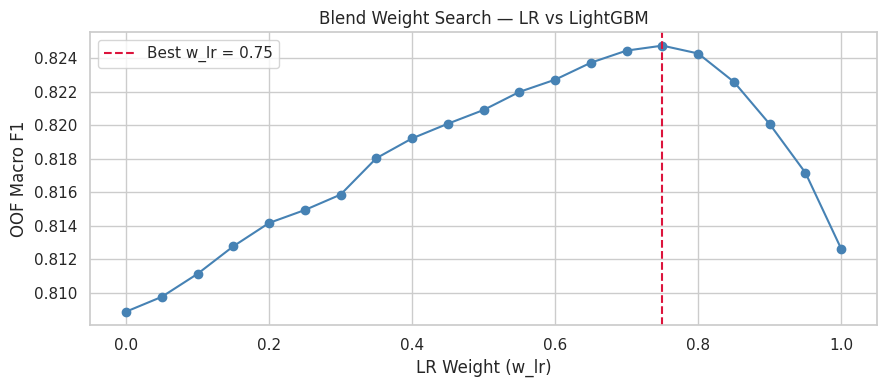

LR alone       : 0.8126
LightGBM alone : 0.8089
Blended        : 0.8248  (LR×0.75 + LGB×0.25)


In [42]:
best_w_lr  = 0.5
best_blend = 0.0
blend_results = []

for w_lr in np.arange(0.0, 1.01, 0.05):
    w_lgb      = 1.0 - w_lr
    blended    = w_lr * oof_proba_lr + w_lgb * oof_proba_lgb
    blend_pred = np.argmax(blended, axis=1)
    blend_f1   = f1_score(y, blend_pred, average='macro')
    blend_results.append({'w_lr': w_lr, 'macro_f1': blend_f1})
    if blend_f1 > best_blend:
        best_blend = blend_f1
        best_w_lr  = w_lr

best_w_lgb = 1.0 - best_w_lr

blend_df = pd.DataFrame(blend_results)

# Plot blend search
plt.figure(figsize=(9, 4))
plt.plot(blend_df['w_lr'], blend_df['macro_f1'], marker='o', color='steelblue')
plt.axvline(best_w_lr, color='crimson', linestyle='--', label=f'Best w_lr = {best_w_lr:.2f}')
plt.xlabel('LR Weight (w_lr)')
plt.ylabel('OOF Macro F1')
plt.title('Blend Weight Search — LR vs LightGBM')
plt.legend()
plt.tight_layout()
plt.show()

lr_alone   = f1_score(y, np.argmax(oof_proba_lr,  axis=1), average='macro')
lgb_alone  = f1_score(y, np.argmax(oof_proba_lgb, axis=1), average='macro')

print(f'LR alone       : {lr_alone:.4f}')
print(f'LightGBM alone : {lgb_alone:.4f}')
print(f'Blended        : {best_blend:.4f}  (LR×{best_w_lr:.2f} + LGB×{best_w_lgb:.2f})')

oof_proba_blend = best_w_lr * oof_proba_lr + best_w_lgb * oof_proba_lgb

## THRESHOLD TUNING ON BLENDED OOF

  STEP 13 — PER-CLASS THRESHOLD TUNING
 Before tuning:
   Accuracy: 0.9139 (91.39%)
   Macro F1: 0.8248
   Label 0: threshold × 0.7  → Macro F1 = 0.8255
   Label 1: threshold × 1.1  → Macro F1 = 0.8257
   Label 2: threshold × 1.0  → Macro F1 = 0.8257
   Label 3: threshold × 1.0  → Macro F1 = 0.8257

 After tuning:
   Accuracy: 0.9144 (91.44%)
   Macro F1: 0.8257  (gain: +0.0010)

Full report (tuned):
              precision    recall  f1-score   support

      Label0       0.98      0.94      0.96    114173
      Label1       0.77      0.82      0.79     15918
      Label2       0.87      0.90      0.89     62440
      Label3       0.64      0.69      0.66      5469

    accuracy                           0.91    198000
   macro avg       0.81      0.84      0.83    198000
weighted avg       0.92      0.91      0.92    198000



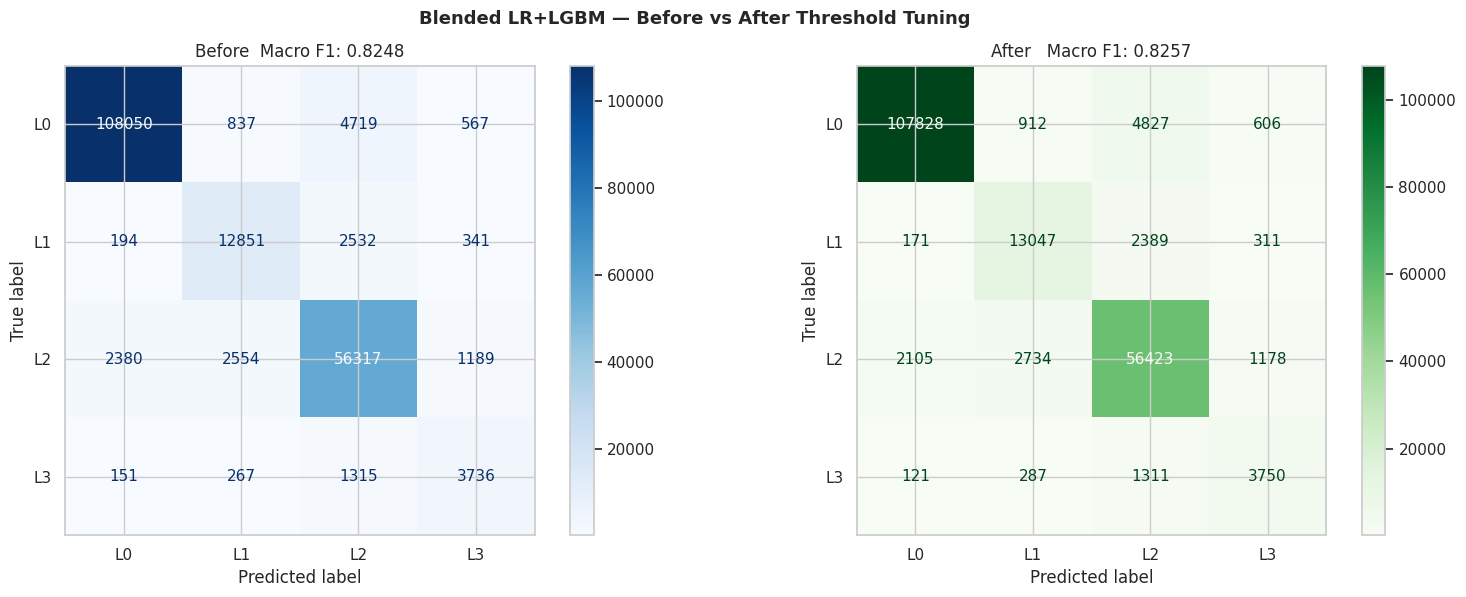

In [43]:
# ================================================================
# STEP 13 — THRESHOLD TUNING ON BLENDED OOF
# ================================================================

print("  STEP 13 — PER-CLASS THRESHOLD TUNING")


oof_pred_default = np.argmax(oof_proba_blend, axis=1)
f1_baseline      = f1_score(y, oof_pred_default, average='macro')
acc_baseline     = accuracy_score(y, oof_pred_default)

print(f" Before tuning:")
print(f"   Accuracy: {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")
print(f"   Macro F1: {f1_baseline:.4f}")

THRESHOLD_GRID  = np.arange(0.5, 3.01, 0.1)
best_thresholds = np.ones(N_CLASSES)
best_f1_tuned   = f1_baseline

for cls in range(N_CLASSES):
    best_t = 1.0
    for t in THRESHOLD_GRID:
        thresholds      = best_thresholds.copy()
        thresholds[cls] = t
        pred            = np.argmax(oof_proba_blend * thresholds, axis=1)
        f1_t            = f1_score(y, pred, average='macro')
        if f1_t > best_f1_tuned:
            best_f1_tuned    = f1_t
            best_t           = t
    best_thresholds[cls] = best_t
    print(f"   Label {cls}: threshold × {best_t:.1f}  → "
          f"Macro F1 = {best_f1_tuned:.4f}")

oof_pred_tuned  = np.argmax(oof_proba_blend * best_thresholds, axis=1)
f1_tuned        = f1_score(y, oof_pred_tuned, average='macro')
acc_tuned       = accuracy_score(y, oof_pred_tuned)

print(f"\n After tuning:")
print(f"   Accuracy: {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"   Macro F1: {f1_tuned:.4f}  (gain: {f1_tuned-f1_baseline:+.4f})")

print(f"\nFull report (tuned):")
print(classification_report(y, oof_pred_tuned,
      target_names=['Label0','Label1','Label2','Label3']))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Blended LR+LGBM — Before vs After Threshold Tuning",
             fontsize=13, fontweight='bold')
ConfusionMatrixDisplay(
    confusion_matrix(y, oof_pred_default),
    display_labels=['L0','L1','L2','L3']
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f"Before  Macro F1: {f1_baseline:.4f}")
ConfusionMatrixDisplay(
    confusion_matrix(y, oof_pred_tuned),
    display_labels=['L0','L1','L2','L3']
).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f"After   Macro F1: {f1_tuned:.4f}")
plt.tight_layout()
plt.savefig("threshold_cm.png", bbox_inches='tight'); plt.show()


In [44]:

LGBM_PARAMS = dict(
    n_estimators      = 700,
    learning_rate     = 0.05,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.9,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.01,
    reg_lambda        = 0.01,
    objective         = 'multiclass',
    num_class         = N_CLASSES,
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
    verbose           = -1,
    max_bin           = 255
)

## RETRAIN FINAL MODELS ON ALL DATA + PREDICT TEST

In [45]:
# ================================================================
# STEP 14 — RETRAIN FINAL MODELS ON ALL DATA + PREDICT TEST
# ================================================================
print("\n" + "=" * 65)
print("  STEP 14 — RETRAIN ON ALL DATA + PREDICT TEST")
print("=" * 65)

mean_best_iter = 785
LR_C=0.5
print(f"  LGBM mean best iter: {mean_best_iter}")

# Final LR
print("\n Training final LR on all 198k rows...")
final_lr = LogisticRegression(
    C            = LR_C,
    penalty      = 'l1',
    solver       = 'liblinear',
    multi_class  = 'ovr',
    max_iter     = 1000,
    class_weight = CUSTOM_WEIGHTS,
    random_state = RANDOM_STATE,
    verbose      = 1,
)
final_lr.fit(X_train_lr, y)
test_proba_lr = final_lr.predict_proba(X_test_lr)
print(f"LR done")

# Final LGBM
print("\n Training final LGBM on all 198k rows...")
FINAL_LGBM = LGBM_PARAMS.copy()
FINAL_LGBM['n_estimators'] = mean_best_iter
final_lgb = lgb.LGBMClassifier(**FINAL_LGBM)
final_lgb.fit(
    X_train_lgb, y,
    sample_weight = sample_weights_train,
    callbacks     = [lgb.log_evaluation(period=100)]
)
test_proba_lgb = final_lgb.predict_proba(X_test_lgb)
print(f" LGBM done")

# Blend test probabilities
test_proba_blend  = best_w_lr * test_proba_lr + best_w_lgb * test_proba_lgb
test_proba_scaled = test_proba_blend * best_thresholds
final_test_preds  = np.argmax(test_proba_scaled, axis=1)

print(f"\n Test prediction distribution:")
for lbl in range(N_CLASSES):
    cnt = (final_test_preds == lbl).sum()
    print(f"   Label {lbl}: {cnt:>7,}  ({cnt/len(final_test_preds)*100:.1f}%)")


import joblib

joblib.dump({
    'lr_model': final_lr,
    'lgb_model': final_lgb,
    'lr_weight': best_w_lr,
    'lgb_weight': best_w_lgb,
    'thresholds': best_thresholds,
    'n_classes': N_CLASSES
}, 'final_blend_model.joblib')

print("\n Final blended model saved as final_blend_model.joblib")




  STEP 14 — RETRAIN ON ALL DATA + PREDICT TEST
  LGBM mean best iter: 785

 Training final LR on all 198k rows...
[LibLinear]iter   1  #CD cycles 1
iter   2  #CD cycles 1
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 3
iter   6  #CD cycles 1
iter   7  #CD cycles 7
iter   8  #CD cycles 1
iter   9  #CD cycles 82
iter  10  #CD cycles 17
iter  11  #CD cycles 1
iter  12  #CD cycles 154
iter  13  #CD cycles 38
iter  14  #CD cycles 1
iter  15  #CD cycles 409
optimization finished, #iter = 15
Objective value = 9742.310511
#nonzeros/#features = 434/35056
iter   1  #CD cycles 1
iter   2  #CD cycles 1
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 3
iter   6  #CD cycles 1
iter   7  #CD cycles 11
iter   8  #CD cycles 1
iter   9  #CD cycles 20
iter  10  #CD cycles 1
iter  11  #CD cycles 175
iter  12  #CD cycles 94
iter  13  #CD cycles 17
iter  14  #CD cycles 1
iter  15  #CD cycles 583
iter  16  #CD cycles 251
iter  17  #CD cycles 3
iter  18  #CD cycles 2
it


```
===============================================================
STEP 14 — RETRAIN ON ALL DATA + PREDICT TEST
===============================================================

LGBM mean best iter: 785

⚙️ Training final LR on all 198k rows...

[LibLinear]
iter 1 #CD cycles 1
iter 2 #CD cycles 1
iter 3 #CD cycles 1
iter 4 #CD cycles 1
iter 5 #CD cycles 3
iter 6 #CD cycles 1
iter 7 #CD cycles 7
iter 8 #CD cycles 1
iter 9 #CD cycles 82
iter 10 #CD cycles 17
iter 11 #CD cycles 1
iter 12 #CD cycles 154
iter 13 #CD cycles 38
iter 14 #CD cycles 1
iter 15 #CD cycles 409
=========================
optimization finished, #iter = 15
Objective value = 9742.310511
#nonzeros/#features = 434/35056
iter   1  #CD cycles 1
iter   2  #CD cycles 1
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 3
iter   6  #CD cycles 1
iter   7  #CD cycles 11
iter   8  #CD cycles 1
iter   9  #CD cycles 20
iter  10  #CD cycles 1
iter  11  #CD cycles 175
iter  12  #CD cycles 94
iter  13  #CD cycles 17
iter  14  #CD cycles 1
iter  15  #CD cycles 583
iter  16  #CD cycles 251
iter  17  #CD cycles 3
iter  18  #CD cycles 2
iter  19  #CD cycles 23
iter  20  #CD cycles 1
WARNING: reaching max number of inner iterations
iter  21  #CD cycles 1000
=========================
optimization finished, #iter = 21
Objective value = 14119.783228
#nonzeros/#features = 1196/35056
iter   1  #CD cycles 1
iter   2  #CD cycles 1
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 4
iter   6  #CD cycles 1
iter   7  #CD cycles 10
iter   8  #CD cycles 1
iter   9  #CD cycles 70
iter  10  #CD cycles 16
iter  11  #CD cycles 1
iter  12  #CD cycles 236
iter  13  #CD cycles 127
iter  14  #CD cycles 7
iter  15  #CD cycles 2
iter  16  #CD cycles 5
iter  17  #CD cycles 1
iter  18  #CD cycles 484
=========================
optimization finished, #iter = 18
Objective value = 17938.161193
#nonzeros/#features = 1253/35056
iter   1  #CD cycles 1
iter   2  #CD cycles 1
iter   3  #CD cycles 1
iter   4  #CD cycles 1
iter   5  #CD cycles 3
iter   6  #CD cycles 1
iter   7  #CD cycles 10
iter   8  #CD cycles 1
iter   9  #CD cycles 42
iter  10  #CD cycles 3
iter  11  #CD cycles 1
iter  12  #CD cycles 323
iter  13  #CD cycles 166
iter  14  #CD cycles 5
iter  15  #CD cycles 17
iter  16  #CD cycles 3
iter  17  #CD cycles 9
iter  18  #CD cycles 4
iter  19  #CD cycles 3
iter  20  #CD cycles 1
iter  21  #CD cycles 974
iter  22  #CD cycles 153
iter  23  #CD cycles 1
WARNING: reaching max number of inner iterations
iter  24  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  25  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  26  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  27  #CD cycles 1000
iter  28  #CD cycles 14
iter  29  #CD cycles 609
iter  30  #CD cycles 9
iter  31  #CD cycles 28
iter  32  #CD cycles 40
iter  33  #CD cycles 641
iter  34  #CD cycles 507
iter  35  #CD cycles 9
iter  36  #CD cycles 3
iter  37  #CD cycles 36
iter  38  #CD cycles 16
iter  39  #CD cycles 407
iter  40  #CD cycles 19
iter  41  #CD cycles 306
iter  42  #CD cycles 197
iter  43  #CD cycles 791
iter  44  #CD cycles 7
iter  45  #CD cycles 18
iter  46  #CD cycles 87
iter  47  #CD cycles 329
iter  48  #CD cycles 195
WARNING: reaching max number of inner iterations
iter  49  #CD cycles 1000
iter  50  #CD cycles 1
WARNING: reaching max number of inner iterations
iter  51  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  52  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  53  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  54  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  55  #CD cycles 1000
WARNING: reaching max number of inner iterations
iter  56  #CD cycles 1000
=========================
optimization finished, #iter = 56
Objective value = 18985.552548
#nonzeros/#features = 3217/35056
LR done
LR done

⚙️ Training final LGBM on all 198k rows...
```

## 
Final Model Loading

In [46]:
import joblib
import numpy as np
import pandas as pd

bundle = joblib.load('/kaggle/input/models/f2000164/final-blend-model/scikitlearn/default/1/final_blend_model.joblib')

final_lr        = bundle['lr_model']
final_lgb       = bundle['lgb_model']
best_w_lr       = bundle['lr_weight']
best_w_lgb      = bundle['lgb_weight']
best_thresholds = bundle['thresholds']
N_CLASSES       = bundle['n_classes']

print(" Model loaded")


 Model loaded


In [47]:

# ================================================================
# STEP 1 — LOAD MODEL
# ================================================================
 
# ================================================================
# STEP 2 — GENERATE PREDICTIONS
# ================================================================
# (Make sure X_test_lr and X_test_lgb already exist)

 
test_proba_lgb = final_lgb.predict_proba(X_test_lgb)
test_proba_lr  = final_lr.predict_proba(X_test_lr)
# test_proba_lgb = models_lgb.predict_proba(X_test_lgb)
# test_proba_lr  = model_lr.predict_proba(X_test_lr)

# Blend
test_proba_blend = (
    best_w_lr * test_proba_lr +
    best_w_lgb * test_proba_lgb
)

# Apply threshold tuning
test_proba_scaled = test_proba_blend * best_thresholds

# Final predictions
final_test_preds = np.argmax(test_proba_scaled, axis=1)

print(" Predictions generated")

# ================================================================
# STEP 3 — CREATE SUBMISSION
# ================================================================
SAMPLE_PATH =  '/kaggle/input/comment-category-prediction-challenge/Sample.csv' # update path if needed

sample_sub = pd.read_csv(SAMPLE_PATH)

# Safety check
assert len(final_test_preds) == len(sample_sub), \
    f"Mismatch: {len(final_test_preds)} vs {len(sample_sub)}"

# Create submission
if 'ID' in test.columns:
    submission = pd.DataFrame({
        'ID': test['ID'].values,
        'label': final_test_preds.astype(int)
    }).sort_values('ID').reset_index(drop=True)
else:
    submission = sample_sub.copy()
    submission['label'] = final_test_preds.astype(int)

# Save
submission.to_csv("submission.csv", index=False)

print("\n submission.csv saved!")
print(f"Shape: {submission.shape}")

# ================================================================
# STEP 4 — CHECK DISTRIBUTION
# ================================================================
print("\nSubmission distribution:")
for lbl in range(N_CLASSES):
    cnt = (submission['label'] == lbl).sum()
    print(f"Label {lbl}: {cnt:,} ({cnt/len(submission)*100:.1f}%)")

# Preview
print("\n First 10 rows:")
print(submission.head(10).to_string(index=False))

 Predictions generated

 submission.csv saved!
Shape: (102000, 2)

Submission distribution:
Label 0: 56,543 (55.4%)
Label 1: 9,014 (8.8%)
Label 2: 32,773 (32.1%)
Label 3: 3,670 (3.6%)

 First 10 rows:
 ID  label
  1      2
  2      2
  3      0
  4      0
  5      0
  6      0
  7      1
  8      0
  9      0
 10      2
